In [16]:
import os
import re
import pandas as pd
from pandas.api.types import is_numeric_dtype
from statsmodels.stats.multitest import multipletests
import numpy as np
import numpy as np, pandas as pd, scipy.stats as ss
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull
# from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from ppca import PPCA
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import chi2_contingency, kruskal

In [258]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [259]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Defines
# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

In [4]:
# Configs
base = r'C:\Dev_AIWM\jupyter\KNN'
cbk = f'{base}\\1212_M02'
raw_path = f'{base}\\1212_M02\\dataset'
crt_path = f'{base}\\1212_M02\\creatures'
result_M01 = f'{base}\\1212_M02\\creatures\\Results\\M01'
m01_c4 = f'{result_M01}\\C4'

In [4]:
## Compare features by Cluster

In [5]:
path1 = f'{crt_path}/Results/M15_dataset08/0531~/WholeExp/C43'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'

dfc = pd.read_csv(os.path.join(path1, "KNN_df_combined_wilcoxon+p_val.csv"))
# dfc.set_index('idx_code', inplace=True)
dfc

,Unnamed: 0,Cluster 1,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,...,Cluster 4,Cluster 40,Cluster 41,Cluster 42,Cluster 43,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
0,sex_sys_val,0.4303 ± 0.4953 (4.4320e-07),0.5246 ± 0.4997 (n.s.),0.5338 ± 0.4993 (n.s.),0.5087 ± 0.5006 (n.s.),0.5802 ± 0.4938 (4.1783e-06),0.5648 ± 0.4963 (0.0081),0.4857 ± 0.5003 (n.s.),0.5547 ± 0.4976 (n.s.),0.4792 ± 0.5000 (n.s.),...,0.3962 ± 0.4900 (0.0004),0.4767 ± 0.5024 (n.s.),0.5260 ± 0.5002 (n.s.),0.5584 ± 0.4975 (n.s.),0.5485 ± 0.4980 (n.s.),0.4523 ± 0.4979 (0.0001),0.4858 ± 0.5001 (n.s.),0.4909 ± 0.5002 (n.s.),0.4812 ± 0.4999 (n.s.),0.4642 ± 0.4996 (n.s.)
1,apgs1,6.7915 ± 1.5433 (2.8174e-248),4.8627 ± 1.9617 (n.s.),5.6855 ± 1.6011 (8.6747e-28),5.3519 ± 1.7356 (6.1867e-08),4.5018 ± 1.8504 (5.9496e-05),4.4330 ± 1.6618 (0.0003),5.0533 ± 1.6718 (0.0029),4.3364 ± 1.5736 (2.8165e-06),4.1085 ± 1.7318 (7.9712e-15),...,5.9887 ± 1.7861 (9.3166e-23),3.4186 ± 1.6625 (2.0122e-09),3.1696 ± 1.6478 (2.9810e-39),3.1533 ± 1.7071 (2.2615e-37),3.4456 ± 1.6567 (5.0483e-74),5.7738 ± 1.7407 (1.5033e-80),5.4929 ± 1.6072 (9.3911e-24),5.6659 ± 1.6685 (7.9223e-46),5.5149 ± 1.6755 (3.0467e-29),4.9727 ± 1.8186 (n.s.)
2,apgs5,8.4845 ± 1.0601 (4.9330e-229),7.1080 ± 1.5932 (n.s.),7.8181 ± 1.1699 (8.4864e-34),7.5865 ± 1.2899 (1.0264e-10),6.8841 ± 1.6566 (n.s.),6.8022 ± 1.4283 (0.0009),7.2286 ± 1.3226 (n.s.),6.5907 ± 1.5005 (2.2180e-08),6.4937 ± 1.5995 (6.5720e-14),...,7.9838 ± 1.1324 (6.5019e-23),5.6977 ± 2.0004 (1.5515e-09),5.6703 ± 1.7068 (1.2208e-36),5.7117 ± 1.7874 (2.5645e-30),5.9542 ± 1.7102 (8.8649e-64),7.9589 ± 1.1994 (1.4397e-111),7.5152 ± 1.2898 (2.9211e-15),7.6847 ± 1.2811 (2.5843e-37),7.5646 ± 1.3286 (1.2565e-22),7.2321 ± 1.3802 (n.s.)
3,bwei,1352.7657 ± 156.6511 (1.7669e-225),1215.9988 ± 232.6737 (1.9733e-31),1131.0480 ± 244.9509 (n.s.),1127.5405 ± 197.7077 (n.s.),1104.7384 ± 232.3869 (n.s.),1050.1582 ± 182.4073 (2.5072e-06),1145.2000 ± 208.7336 (0.0032),898.5426 ± 192.7203 (2.8661e-46),932.8698 ± 205.3928 (2.9220e-44),...,1310.2000 ± 166.5650 (5.4804e-35),936.0930 ± 310.0707 (4.1917e-06),670.6228 ± 136.3026 (2.1154e-112),835.9380 ± 176.9748 (1.6103e-49),811.7304 ± 190.5870 (2.1232e-152),1296.4419 ± 179.3915 (4.0109e-163),1258.8725 ± 176.2411 (5.5640e-54),1353.7749 ± 193.0927 (2.0032e-164),1295.5845 ± 170.8809 (6.6852e-107),1303.3311 ± 186.1783 (1.7373e-34)
4,mage,34.2378 ± 3.6645 (4.6210e-11),32.6279 ± 4.3378 (1.4083e-09),33.7367 ± 4.1606 (n.s.),34.7023 ± 4.7841 (1.0711e-07),33.7837 ± 4.7706 (0.0005),33.4813 ± 4.3790 (n.s.),34.5029 ± 3.6259 (1.4419e-09),33.5596 ± 3.6942 (n.s.),32.4358 ± 4.2826 (3.0061e-08),...,32.8943 ± 4.9738 (n.s.),34.3140 ± 3.2585 (n.s.),32.8201 ± 4.7510 (n.s.),33.6752 ± 3.4768 (n.s.),32.0863 ± 4.6579 (5.7265e-17),33.1647 ± 4.2313 (0.0061),31.9104 ± 4.3005 (1.0905e-21),34.4630 ± 3.5748 (1.9231e-15),32.4962 ± 4.7675 (5.4010e-09),35.9590 ± 4.5637 (3.6415e-24)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,iperr_4,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0019 ± 0.0436 (n.s.),0.0000 ± 0.0000 (n.s.),0.0018 ± 0.0425 (n.s.),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)
144,iperroy_1,0.9973 ± 0.0515 (4.1998e-06),0.9965 ± 0.0593 (0.0001),0.9840 ± 0.1256 (n.s.),0.9913 ± 0.0928 (n.s.),0.9895 ± 0.1018 (n.s.),0.9868 ± 0.1142 (n.s.),0.9962 ± 0.0617 (0.0036),0.9781 ± 0.1465 (n.s.),0.9675 ± 0.1776 (n.s.),...,0.9962 ± 0.0614 (n.s.),0.9186 ± 0.2750 (0.0002),0.8581 ± 0.3495 (1.4452e-43),0.9416 ± 0.2349 (4.8596e-05),0.9296 ± 0.2560 (1.0459e-19),0.9970 ± 0.0545 (6.7786e-07),0.9946 ± 0.0735 (0.0015),0.9989 ± 0.0327 (6.7353e-06),0.9957 ± 0.0655 (0.0001),1.0000 ± 0.0000 (0.0091)
145,iperroy_4,0.00

In [ ]:
for column in dfc.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {dfc[column].dtype}")
    print(f"유니크한 값:")
    print(dfc[column].unique())
    print("-" * 40)

In [62]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0531~/WholeExp/C43'
ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/C18_'

df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})

df_ana['date36']  = pd.to_datetime(df_ana['date36'],  errors='coerce', format='%Y-%m-%d')
df_ana['birthdt'] = pd.to_datetime(df_ana['birthdt'], errors='coerce', format='%Y-%m-%d')
# 교정 36주까지 생후 일수(cga) 계산
df_ana['cga'] = ((df_ana['date36'] - df_ana['birthdt']).dt.days).astype('Int64')

# missing = df_ana[['date36', 'birthdt']].isna().sum()
print(df_ana[['date36']].isna().sum())
print(df_ana[['birthdt']].isna().sum())
print(df_ana[['date36', 'birthdt', 'cga']])

# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

date36    5024
dtype: int64
birthdt    0
dtype: int64
             date36    birthdt   cga
idx_code                            
0        2014-01-25 2013-12-18    38
1        2014-01-24 2013-11-15    70
2        2014-01-01 2013-11-15    47
3        2014-01-01 2013-11-15    47
4        2014-01-11 2013-11-11    61
...             ...        ...   ...
20408           NaT 2022-11-28  <NA>
20409           NaT 2022-12-27  <NA>
20410           NaT 2022-12-01  <NA>
20411           NaT 2022-11-30  <NA>
20412           NaT 2022-11-30  <NA>

[20352 rows x 3 columns]


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20248\2681752374.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))


,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,cga
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,4.0,5.0,1350,29,1,0,39.0,0.0,28.0,...,0,1,0,0,0,1,0,0,0,38
1,1,4.0,5.0,790,35,1,0,34.3,0.0,23.0,...,0,1,0,0,0,1,0,0,0,70
2,1,5.0,6.0,1400,26,1,0,39.0,0.0,28.5,...,0,1,0,0,0,1,0,0,0,47
3,1,6.0,7.0,1340,26,1,0,36.0,0.0,28.0,...,0,1,0,0,0,1,0,0,0,47
4,1,4.0,5.0,1240,36,4,1,42.0,0.0,26.5,...,0,1,0,0,0,1,0,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,5.0,8.0,1350,23,1,0,37.5,0.0,27.5,...,0,1,0,0,0,1,0,0,0,<NA>
20409,1,4.0,7.0,860,38,3,1,33.5,0.0,23.5,...,0,1,0,0,0,1,0,0,0,<NA>
20410,0,5.0,7.0,1910,30,2,0,42.5,0.0,29.0,...,0,1,0,0,0,1,0,0,0,<NA>


TypeError: float() argument must be a string or a number, not 'NAType'

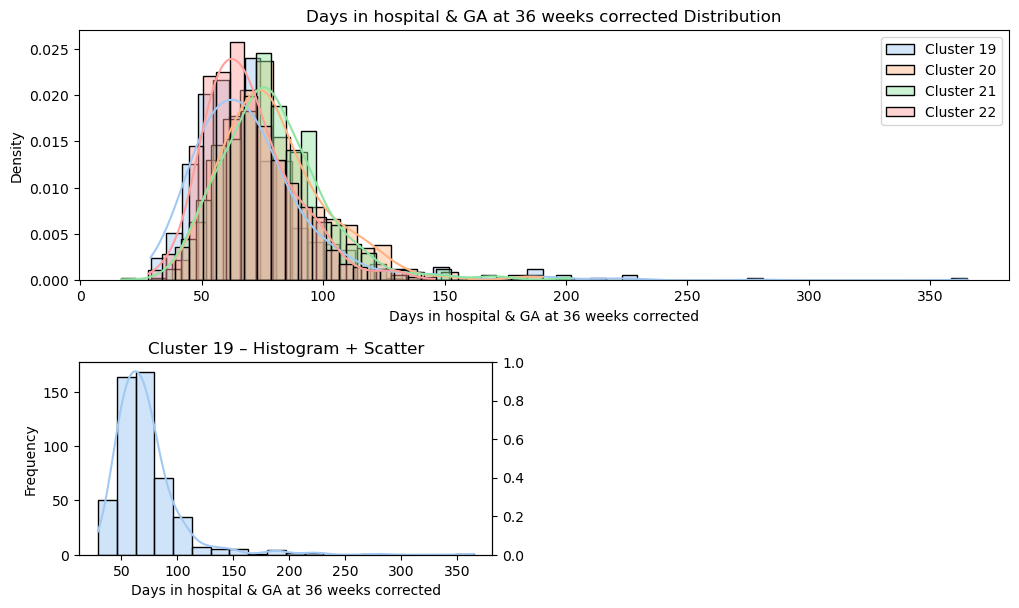

In [20]:
col = 'Days in hospital & GA at 36 weeks corrected'
selected_clusters = [19, 20, 21, 22]

# Filter labels & data to only clusters below
mask = cluster_labels.isin(selected_clusters)
filtered_clusters = cluster_labels[mask]
filtered_df       = df_scd.loc[mask]

ga       = filtered_df['stday']
other_var = 'cga'



clusters = filtered_clusters
cl_ids   = sorted(selected_clusters)
colours = sns.color_palette("pastel", n_colors=len(cl_ids))

# — Build the figure exactly as before —
n  = len(cl_ids)
fig = plt.figure(figsize=(12, 3.5*(n+1)))
gs  = gridspec.GridSpec(
        nrows=n+1, ncols=2,
        height_ratios=[1.3] + [1]*n,
        hspace=0.4, wspace=0.25
      )

# (A) Overall distribution of only the selected clusters
ax_all = fig.add_subplot(gs[0, :])
for cl, colour in zip(cl_ids, colours):
    sns.histplot(
        ga[clusters == cl], stat='density', kde=True,
        color=colour, label=f'Cluster {cl}',
        alpha=0.45, edgecolor='black', ax=ax_all
    )
# ax_all.set_title(f'Birth to {col} Achieving (≥100 ml/kg/day) Distribution')
# ax_all.set_xlabel(f'Birth to {col} Achieving (Days)')
ax_all.set_title(f'{col} Distribution')
ax_all.set_xlabel(f'{col}')

ax_all.set_ylabel('Density')
ax_all.legend()

# (B) Per-cluster histogram + Q-Q plot
for i, (cl, colour) in enumerate(zip(cl_ids, colours), start=1):
    subset_x = ga[clusters == cl].dropna()                # x축: bdp
    subset_y = filtered_df.loc[clusters == cl, other_var] # y축: 다른 변수

    # ─ Histogram ─
    ax_hist = fig.add_subplot(gs[i, 0])
    sns.histplot(subset_x, bins=20, kde=True,
                 color=colour, edgecolor='black', ax=ax_hist)
    ax_hist.set_title(f'Cluster {cl} – Histogram + Scatter')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frequency')

    # ─ Scatter overlay (second y-axis) ─
    ax_scatter = ax_hist.twinx()            # 보조 y축
    ax_scatter.scatter(subset_x, subset_y,
                       s=20,               # 점 크기
                       alpha=0.6,
                       color='royalblue',
                       edgecolors='none')
    ax_scatter.set_ylabel(other_var)
    ax_scatter.grid(False)                 # 그리드 겹침 방지

    # 눈금 좌우 겹침이 거슬리면:
    ax_scatter.tick_params(axis='y', colors='royalblue')
    ax_hist.tick_params(axis='y', colors='black')

    # Q-Q plot
    ax_qq = fig.add_subplot(gs[i, 1])
    stats.probplot(subset, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor(colour)
    ax_qq.get_lines()[0].set_markeredgecolor(colour)
    ax_qq.get_lines()[1].set_color('crimson')
    ax_qq.set_title(f'Cluster {cl} – Q-Q Plot')
    ax_qq.set_xlabel('Theoretical quantiles')
    ax_qq.set_ylabel('Ordered values')

plt.tight_layout()
fig.savefig(os.path.join(ipt_dir, f'{col}-days_Histo+KDE-QQ_plt.pdf'),
            bbox_inches='tight')
plt.show()
plt.close(fig)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20248\2204459040.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


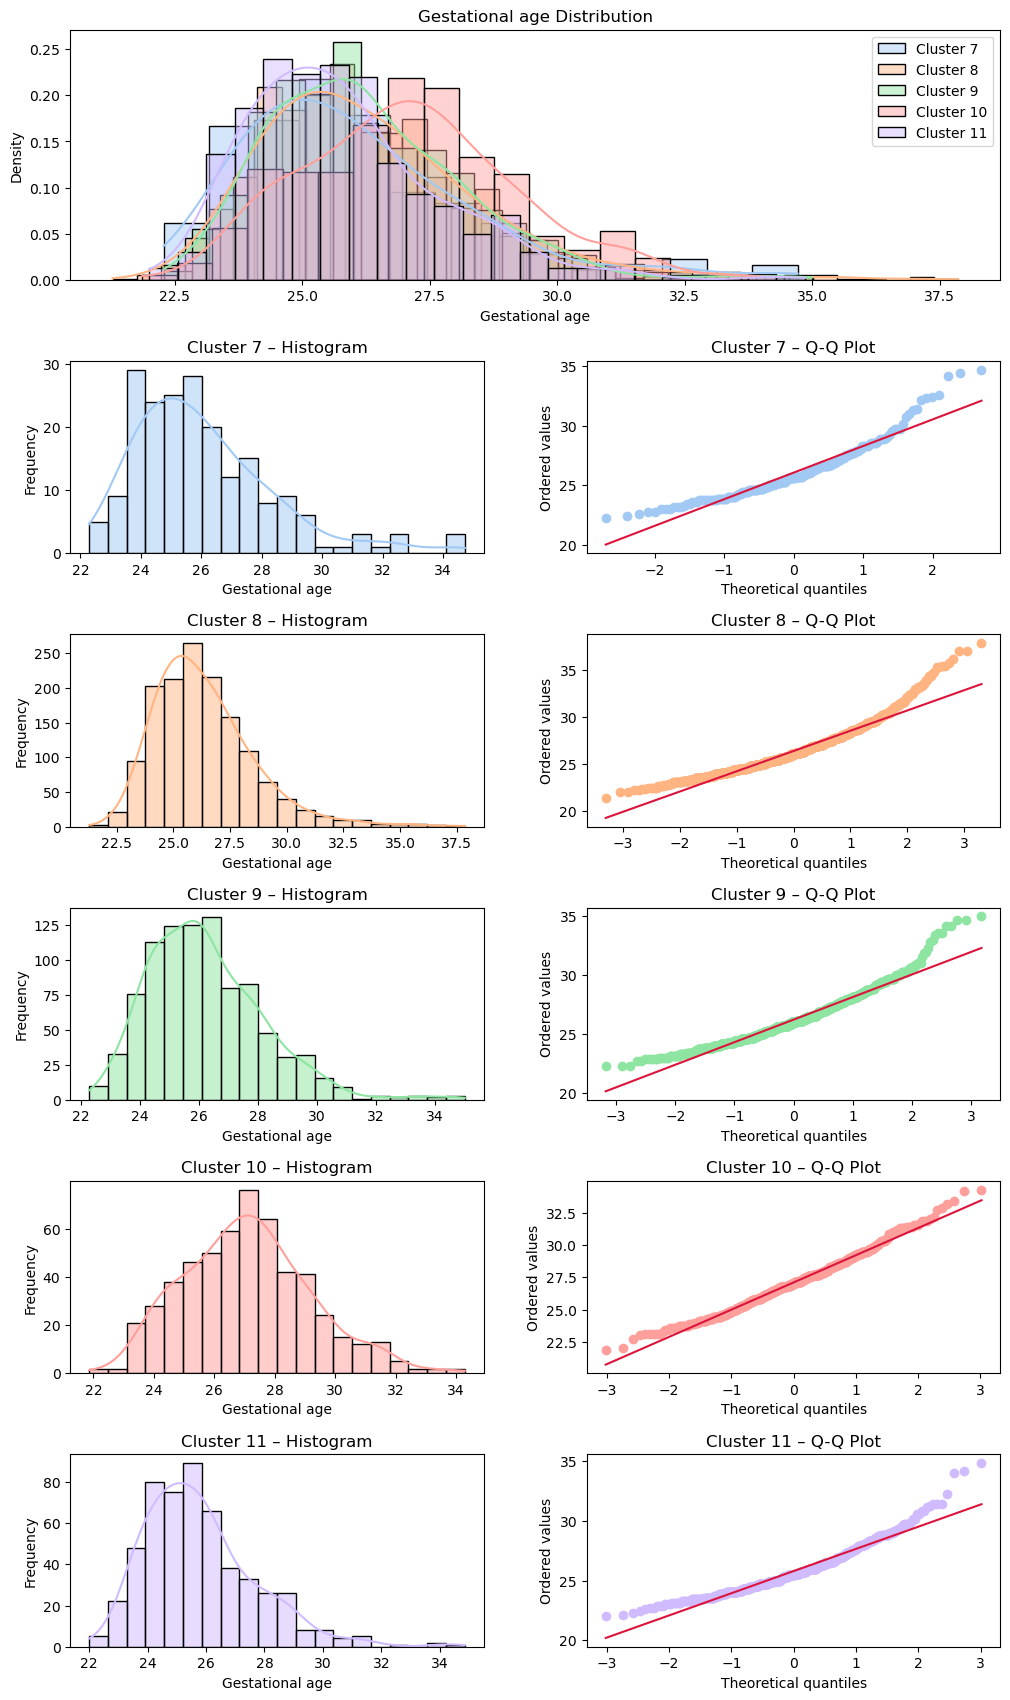

In [89]:
col = 'Gestational age'
selected_clusters = [7, 8, 9, 10, 11]

# Filter labels & data to only clusters below
mask = cluster_labels.isin(selected_clusters)
filtered_clusters = cluster_labels[mask]
filtered_df       = df_scd.loc[mask]

ga       = filtered_df['ga']



clusters = filtered_clusters
cl_ids   = sorted(selected_clusters)
colours = sns.color_palette("pastel", n_colors=len(cl_ids))

# — Build the figure exactly as before —
n  = len(cl_ids)
fig = plt.figure(figsize=(12, 3.5*(n+1)))
gs  = gridspec.GridSpec(
        nrows=n+1, ncols=2,
        height_ratios=[1.3] + [1]*n,
        hspace=0.4, wspace=0.25
      )

# (A) Overall distribution of only the selected clusters
ax_all = fig.add_subplot(gs[0, :])
for cl, colour in zip(cl_ids, colours):
    sns.histplot(
        ga[clusters == cl], stat='density', kde=True,
        color=colour, label=f'Cluster {cl}',
        alpha=0.45, edgecolor='black', ax=ax_all
    )
# ax_all.set_title(f'Birth to {col} Achieving (≥100 ml/kg/day) Distribution')
# ax_all.set_xlabel(f'Birth to {col} Achieving (Days)')
ax_all.set_title(f'{col} Distribution')
ax_all.set_xlabel(f'{col}')

ax_all.set_ylabel('Density')
ax_all.legend()

# (B) Per-cluster histogram + Q-Q plot
for i, (cl, colour) in enumerate(zip(cl_ids, colours), start=1):
    subset = ga[clusters == cl].dropna()

    # Histogram
    ax_hist = fig.add_subplot(gs[i, 0])
    sns.histplot(subset, bins=20, kde=True,
                 color=colour, edgecolor='black', ax=ax_hist)
    ax_hist.set_title(f'Cluster {cl} – Histogram')
#     ax_hist.set_xlabel(f'Birth to {col} Achieving (Days)')
    ax_hist.set_xlabel(f'{col}')
    ax_hist.set_ylabel('Frequency')

    # Q-Q plot
    ax_qq = fig.add_subplot(gs[i, 1])
    stats.probplot(subset, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor(colour)
    ax_qq.get_lines()[0].set_markeredgecolor(colour)
    ax_qq.get_lines()[1].set_color('crimson')
    ax_qq.set_title(f'Cluster {cl} – Q-Q Plot')
    ax_qq.set_xlabel('Theoretical quantiles')
    ax_qq.set_ylabel('Ordered values')

plt.tight_layout()
fig.savefig(os.path.join(ipt_dir, f'{col}_Histo+KDE-QQ_plt.pdf'),
            bbox_inches='tight')
plt.show()
plt.close(fig)

In [55]:
target_clusters = [7, 8, 9, 10, 11]
df_ana1 = df_ana[df_ana['Cluster_Labels'].isin(target_clusters)].copy()

clusters = np.sort(df_ana1['Cluster_Labels'].dropna().unique())

# 1) 변수 유형 분류
continuous_cols = []
categorical_cols = []
for col in df_ana1.columns:
    if col == 'Cluster_Labels':
        continue
    ser = df_ana1[col]
    is_trms = bool(re.match(r'^(trmsitr|trmstr)', col, re.I))
    if pd.api.types.is_numeric_dtype(ser):
        uniq = ser.dropna().unique()
        if is_trms:
            continuous_cols.append(col)
        elif len(uniq) <= 2 and set(uniq).issubset({0, 1}):
            categorical_cols.append(col)
        else:
            continuous_cols.append(col)
    else:
        categorical_cols.append(col)

# 2) 포맷팅 함수 및 저장할 리스트 준비
def fmt_p_value(p):
    if p is None:      return "N/A"
    if p < 0.001:      return "< 0.001"
    return f"{min(p, 0.999):.3f}"

FMT_NPCT     = "{n:d} ({pct:.1f}%)"
FMT_MED_IQR  = "{med:.2f} ({p25:.2f}-{p75:.2f})"
table_rows   = []

# 3) χ² 검정 (binary)
for col in categorical_cols:
    sub = df_ana1[['Cluster_Labels', col]].dropna()
    if sub[col].nunique() == 0:
        continue
    sub = sub[~sub.index.duplicated(keep='first')]

    # 원본 교차표
    orig_cont = pd.crosstab(sub[col], sub['Cluster_Labels']) \
                 .reindex(columns=clusters, fill_value=0)
    orig_cont = orig_cont.loc[orig_cont.sum(axis=1)>0, :]
    orig_cont = orig_cont.loc[:, orig_cont.sum(axis=0)>0]

    # p_chi 계산
    if orig_cont.shape[0] < 2 or orig_cont.shape[1] < 2:
        p_chi = np.nan
    else:
        p_chi = chi2_contingency(orig_cont, correction=False)[1]

    # positive 레벨만 필터
    cont = orig_cont.copy()
    levels = list(cont.index)
    if set(levels) <= {0, 1}:
        pos = 1 if 1 in levels else 0
        cont = cont.loc[[pos], :]

    # counts 및 비율 계산
    cluster_n = sub['Cluster_Labels'].value_counts().reindex(clusters, fill_value=0)
    counts    = cont.iloc[0]
    row       = {'Var_columns': col}
    for cl in clusters:
        denom = cluster_n[cl]
        pct   = 0 if denom == 0 else 100 * counts.get(cl, 0) / denom
        row[f'Cluster {cl}'] = FMT_NPCT.format(n=int(counts.get(cl, 0)), pct=pct)
    row['p_value'] = fmt_p_value(p_chi)
    table_rows.append(row)

# 4) Kruskal–Wallis 검정 (continuous)
for col in continuous_cols:
    samples = [df_ana1.loc[df_ana1['Cluster_Labels']==cl, col].dropna()
               for cl in clusters]
    combined = pd.concat(samples)
    p_kw = None if combined.nunique() <= 1 else kruskal(*samples).pvalue

    row = {'Var_columns': col}
    for cl, s in zip(clusters, samples):
        med, p25, p75 = s.median(), *s.quantile([0.25, 0.75])
        row[f'Cluster {cl}'] = FMT_MED_IQR.format(med=med, p25=p25, p75=p75)
    row['p_value'] = fmt_p_value(p_kw)
    table_rows.append(row)

# 5) 요약 DataFrame 완성
summary_df = pd.DataFrame(table_rows)
summary_df = summary_df[["Var_columns", *[f"Cluster {c}" for c in clusters], "p_value"]]
summary_df

,Var_columns,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,p_value
0,sex_sys_val,112 (55.4%),774 (53.1%),536 (57.9%),284 (52.2%),267 (49.7%),0.026
1,bheiuk,10 (5.0%),176 (12.1%),84 (9.1%),42 (7.7%),80 (14.9%),< 0.001
2,bheaduk,10 (5.0%),184 (12.6%),87 (9.4%),44 (8.1%),88 (16.4%),< 0.001
3,btemuk,4 (2.0%),104 (7.1%),32 (3.5%),18 (3.3%),17 (3.2%),< 0.001
4,bbphuk,0 (0.0%),488 (33.5%),309 (33.4%),91 (16.7%),129 (24.0%),< 0.001
...,...,...,...,...,...,...,...
143,NTET_day,17.00 (9.00-41.00),15.00 (9.00-29.00),13.00 (7.00-27.00),15.50 (9.00-27.00),19.00 (9.00-32.00),0.273
144,IPERR_day,18.00 (9.50-23.00),12.00 (8.00-23.00),8.50 (5.75-14.00),14.50 (8.00-23.00),13.00 (8.50-20.50),0.014
145,EFYN_day,40.00 (26.00-57.00),40.00 (24.00-59.25),37.00 (24.00-53.00),36.00 (23.00-49.00),43.00 (25.00-63.00),< 0.001
146,ga,25.57 (24.43-27.14),26.00 (24.71-27.43),26.00 (24.71-27.43),27.00 (25.57-28.43),25.43 (24.43-26.71),< 0.001


In [56]:
summary_df.to_csv(os.path.join(ipt_dir, "chiSq+KW_results.csv"))    # , index=False

In [57]:
summary_df

,Var_columns,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,p_value
0,sex_sys_val,112 (55.4%),774 (53.1%),536 (57.9%),284 (52.2%),267 (49.7%),0.026
1,bheiuk,10 (5.0%),176 (12.1%),84 (9.1%),42 (7.7%),80 (14.9%),< 0.001
2,bheaduk,10 (5.0%),184 (12.6%),87 (9.4%),44 (8.1%),88 (16.4%),< 0.001
3,btemuk,4 (2.0%),104 (7.1%),32 (3.5%),18 (3.3%),17 (3.2%),< 0.001
4,bbphuk,0 (0.0%),488 (33.5%),309 (33.4%),91 (16.7%),129 (24.0%),< 0.001
...,...,...,...,...,...,...,...
143,NTET_day,17.00 (9.00-41.00),15.00 (9.00-29.00),13.00 (7.00-27.00),15.50 (9.00-27.00),19.00 (9.00-32.00),0.273
144,IPERR_day,18.00 (9.50-23.00),12.00 (8.00-23.00),8.50 (5.75-14.00),14.50 (8.00-23.00),13.00 (8.50-20.50),0.014
145,EFYN_day,40.00 (26.00-57.00),40.00 (24.00-59.25),37.00 (24.00-53.00),36.00 (23.00-49.00),43.00 (25.00-63.00),< 0.001
146,ga,25.57 (24.43-27.14),26.00 (24.71-27.43),26.00 (24.71-27.43),27.00 (25.57-28.43),25.43 (24.43-26.71),< 0.001


In [58]:
Fn   = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'
df_dict = pd.read_excel(os.path.join(Fn, 'C4_sort(ana+desc)_EN.xlsx'))
df_dict

,cat_name,Feature name,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,NaN,NaN,NaN,"Near‑term, low risk, very high survival\n""Stea...","Extreme pre‑term, early cardiorespiratory cras...","Severe GI morbidity managed by intensive care,...","Moderate prematurity, well‑managed course, min..."
1,NaN,NaN,Decease / Total (%),25 / 8009 (0.31%),2285 / 2392 (95.53%),171 / 2908 (5.88%),110 / 7043 (1.56%)
2,NaN,NaN,IBP (Pos) / Total (%),23 / 8009 (0.29%),136 / 2392 (5.69%),179 / 2908 (6.16%),120 / 7043 (1.70%)
3,NaN,NaN,NEC (Pos) / Total (%),127 / 8009 (1.59%),344 / 2392 (14.38%),395 / 2908 (13.58%),416 / 7043 (5.91%)
4,NaN,NaN,And (Pos) / Total (%),4 / 8009 (0.05%),52 / 2392 (2.17%),53 / 2908 (1.82%),37 / 7043 (0.53%)
...,...,...,...,...,...,...,...
164,Reason of Death,Cause of death: Neurological,death_NL,0.0001 ± 0.0112 (2.8384e-35),0.0966 ± 0.2954 (0.0000e+00),0.0017 ± 0.0414 (5.9705e-08),0.0003 ± 0.0169 (2.4787e-28)
165,Reason of Death,Cause of death: Infection,death_Inf,0.0007 ± 0.0274 (7.4706e-58),0.1484 ± 0.3556 (0.0000e+00),0.0113 ± 0.1059 (0.0002),0.0034 ± 0.0583 (4.8458e-36)
166,Reason of Death,Cause of death: Gastrointestinal,death_GI,0.0010 ± 0.0316 (3.1543e-39),0.0949 ± 0.2931 (9.2336e-263),0.0096 ± 0.0977 (n.s.),0.0053 ± 0.0723 (3.0941e-16)
167,Reason of Death,Cause of death: Congenital anomalies,death_CA,0.0002 ± 0.0158 (1.3162e-13),0.0309 ± 0.1732 (8.4029e-91),0.0021 ± 0.0454 (n.s.),0.0017 ± 0.0412 (8.1449e-06)


In [59]:
desc_cols = ['col_name'] + [c for c in df_dict.columns 
                            if c.startswith("Feature ")]
df_dict = df_dict[desc_cols].drop_duplicates(subset="col_name")


summary_df = summary_df.rename(columns={'Var_columns': 'col_name'})
merged = summary_df.merge(
    df_dict[['Feature name', 'col_name']],
    on='col_name',
    how='left'
)

cluster_cols = [c for c in merged.columns if c.startswith("Cluster ")]
ordered_cols = [
    "Feature name", "col_name",
    *cluster_cols,
    "p_value"
]

# ordered_cols = (
#     ["col_name"] +
#     sorted([c for c in merged.columns if c.startswith("Var_names_")]) +
#     cluster_cols +
#     ["p_value"]
# )


# merged = merged[ordered_cols]
# order = [v for v in df_dict["Var_columns"] if v in merged["Var_columns"].values]
# merged = merged.set_index("Var_columns").reindex(order).reset_index()

# cluster_cols = sorted([c for c in merged.columns if c.startswith("Cluster ")],
#                       key=lambda x: int(x.split()[-1]))

merged = merged[ordered_cols]
merged

,Feature name,col_name,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,p_value
0,Sex (Male),sex_sys_val,112 (55.4%),774 (53.1%),536 (57.9%),284 (52.2%),267 (49.7%),0.026
1,Birth length (Unknown),bheiuk,10 (5.0%),176 (12.1%),84 (9.1%),42 (7.7%),80 (14.9%),< 0.001
2,Head circumference (Unknown),bheaduk,10 (5.0%),184 (12.6%),87 (9.4%),44 (8.1%),88 (16.4%),< 0.001
3,Admission body temperature (Unknown),btemuk,4 (2.0%),104 (7.1%),32 (3.5%),18 (3.3%),17 (3.2%),< 0.001
4,Blood-gas pH within 1 h of birth (Unknown),bbphuk,0 (0.0%),488 (33.5%),309 (33.4%),91 (16.7%),129 (24.0%),< 0.001
...,...,...,...,...,...,...,...,...
143,Necrotising enterocolitis (Stage ≥ 2),NTET_day,17.00 (9.00-41.00),15.00 (9.00-29.00),13.00 (7.00-27.00),15.50 (9.00-27.00),19.00 (9.00-32.00),0.273
144,Idiopathic bowel perforation,IPERR_day,18.00 (9.50-23.00),12.00 (8.00-23.00),8.50 (5.75-14.00),14.50 (8.00-23.00),13.00 (8.50-20.50),0.014
145,Enteral feeds ≥100 ml/kg/day before discharge,EFYN_day,40.00 (26.00-57.00),40.00 (24.00-59.25),37.00 (24.00-53.00),36.00 (23.00-49.00),43.00 (25.00-63.00),< 0.001
146,Gestational age,ga,25.57 (24.43-27.14),26.00 (24.71-27.43),26.00 (24.71-27.43),27.00 (25.57-28.43),25.43 (24.43-26.71),< 0.001


In [61]:
merged.to_excel(os.path.join(ipt_dir, "fin(chiSq+KW_results).xlsx"), index=False)

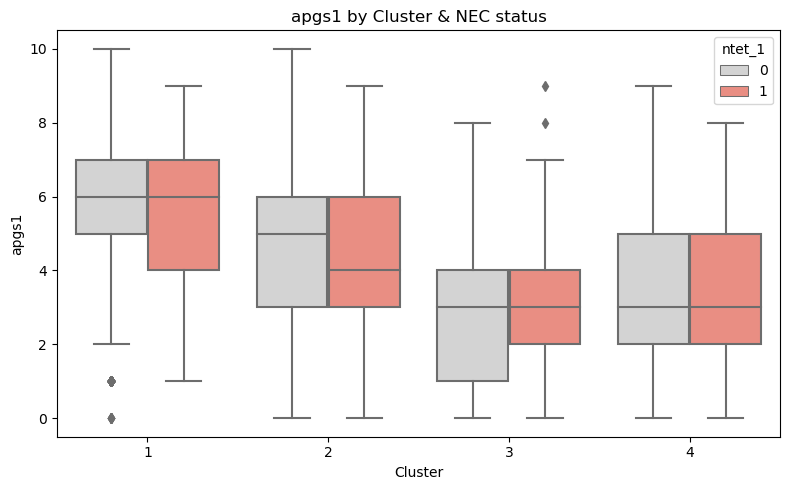

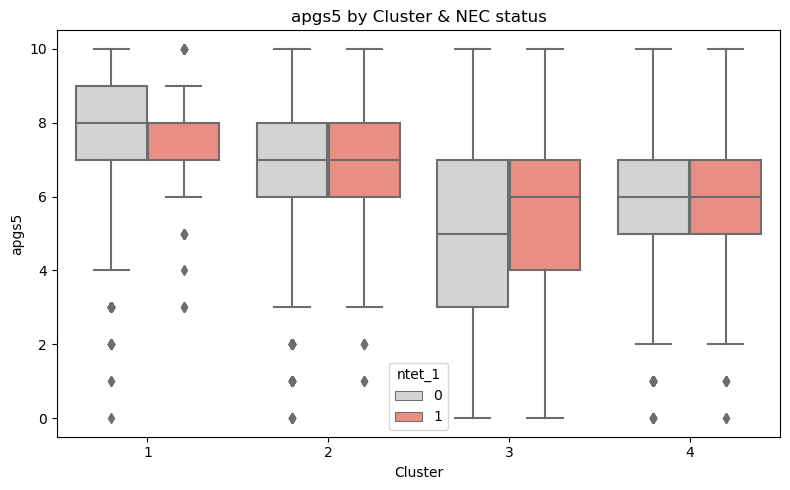

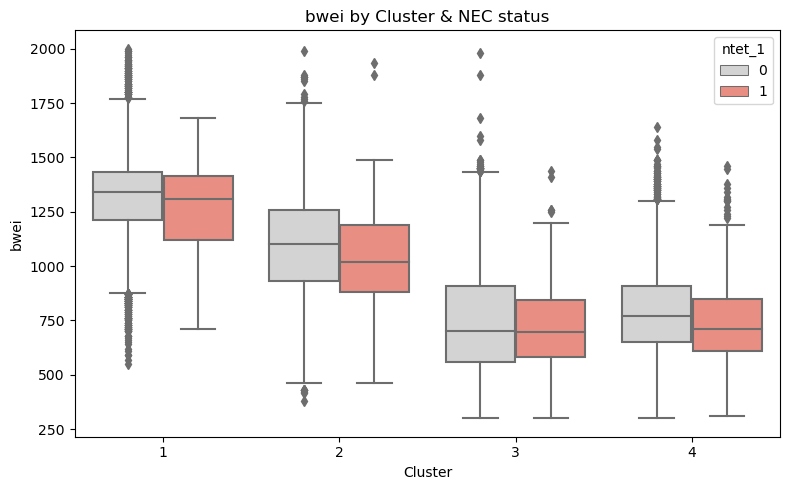

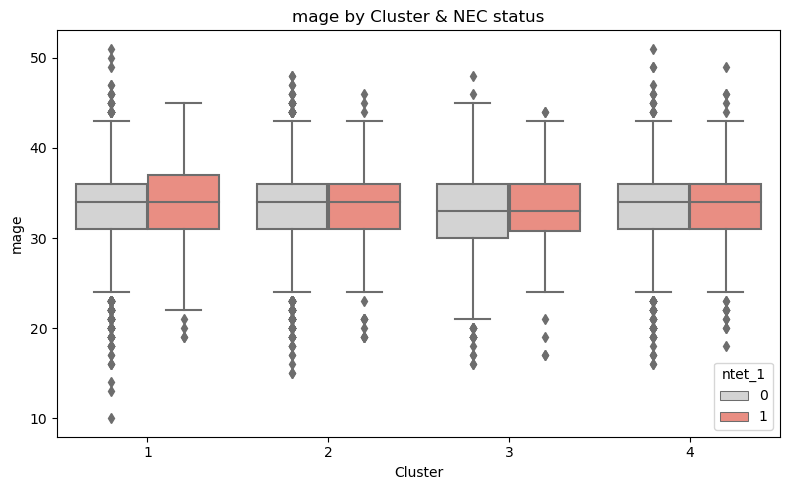

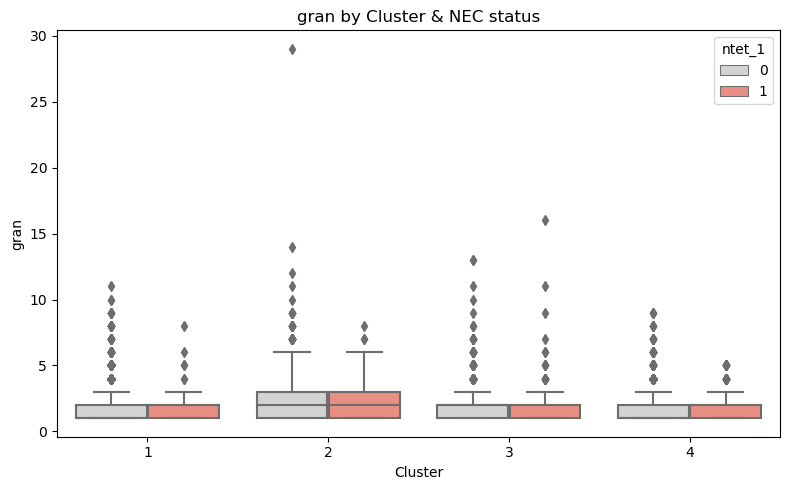

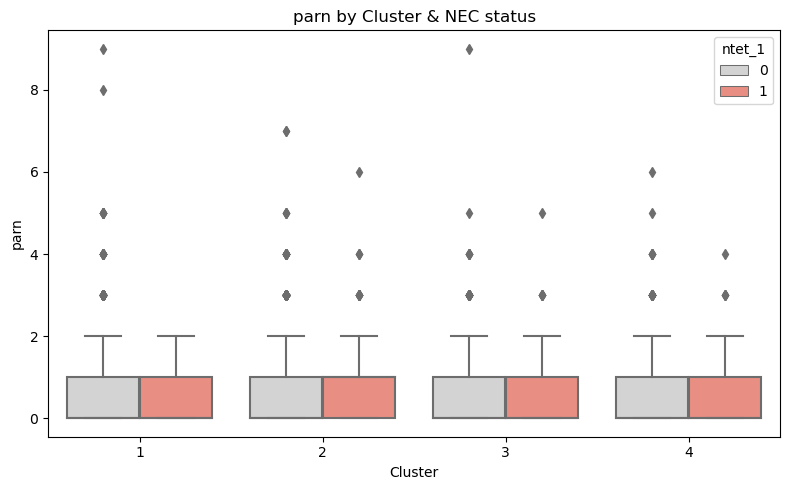

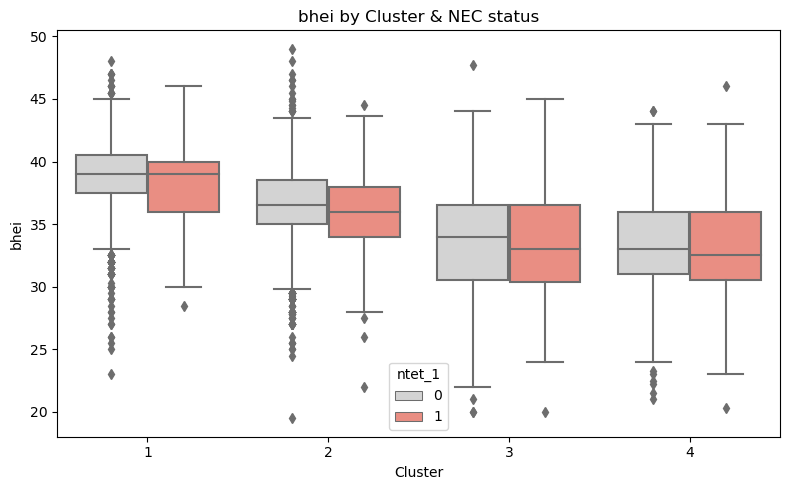

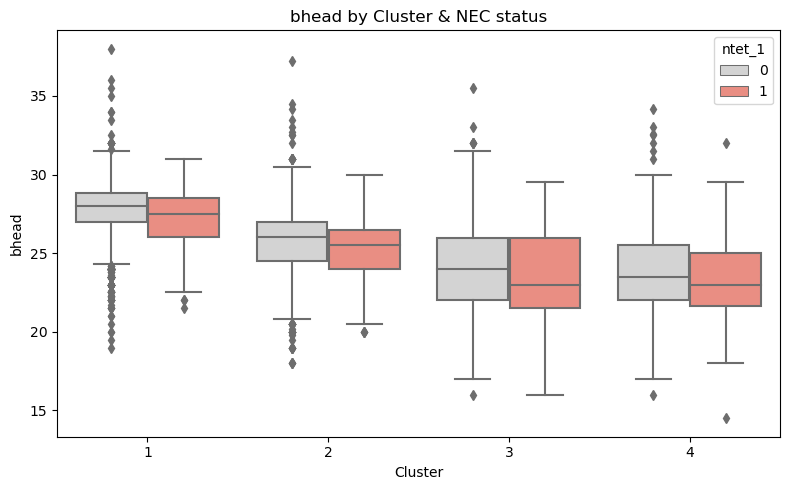

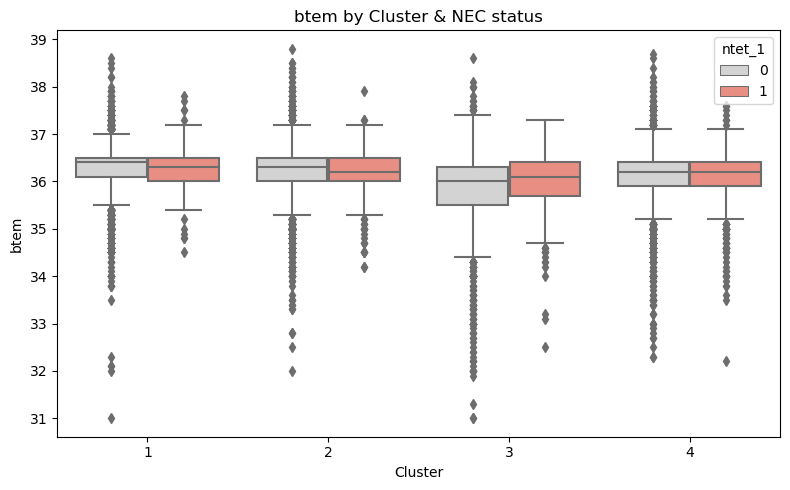

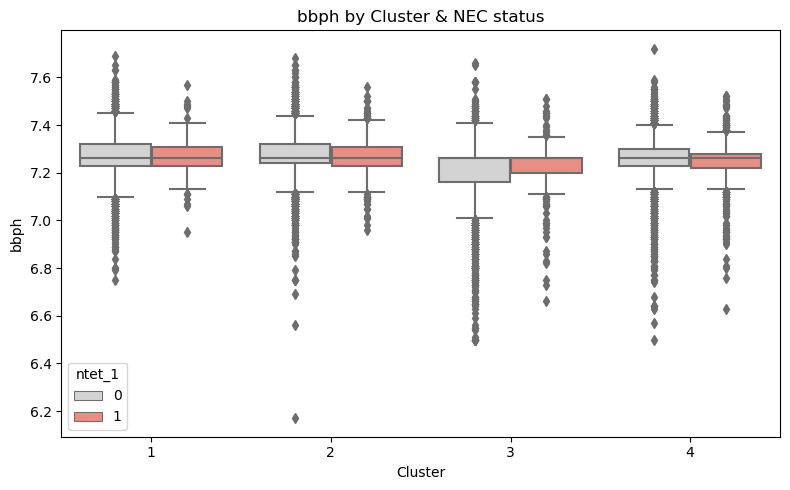

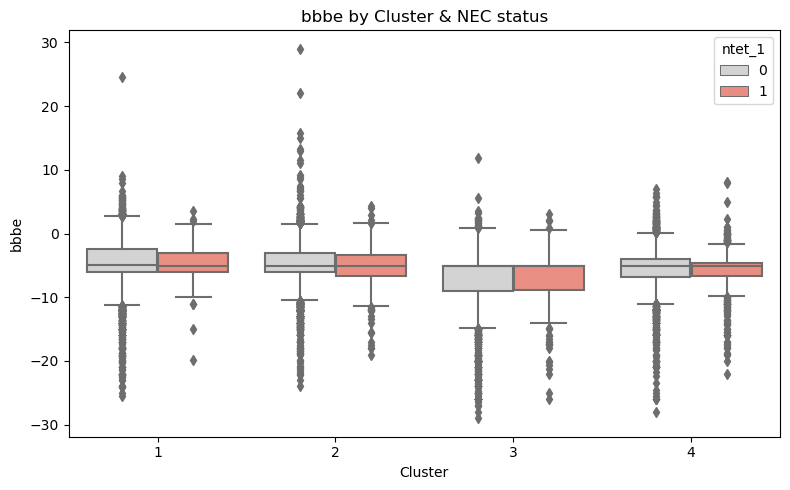

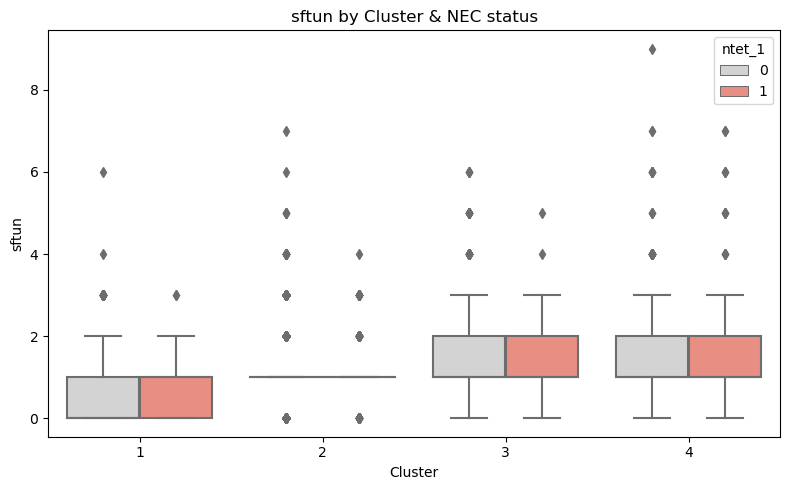

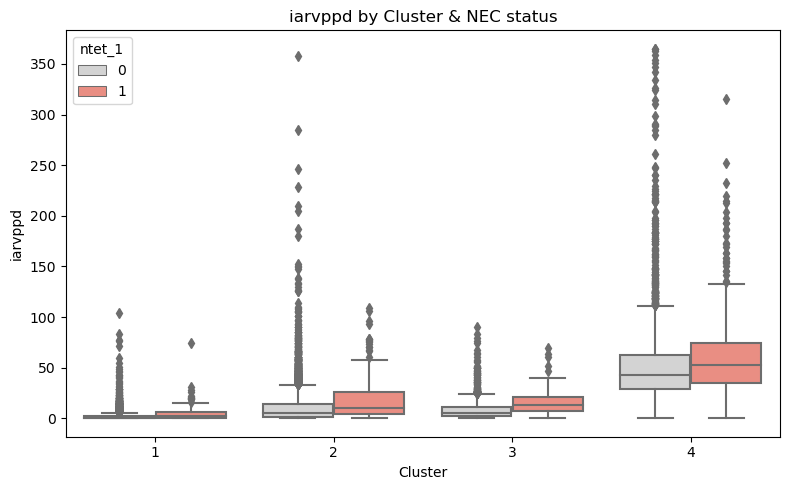

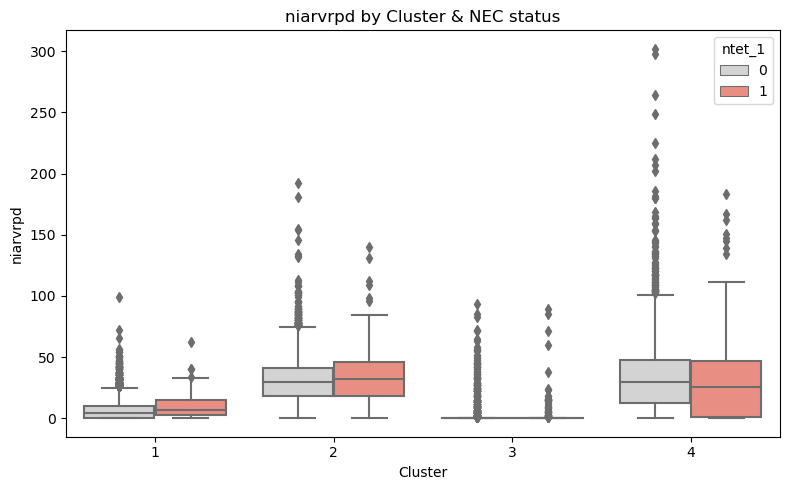

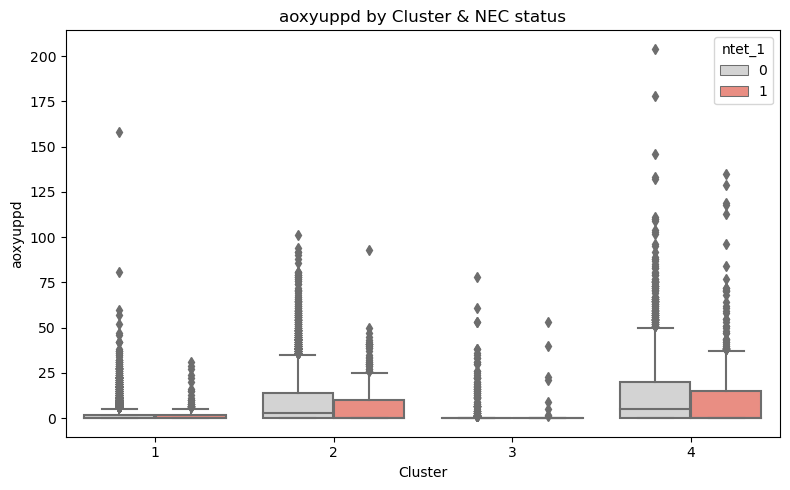

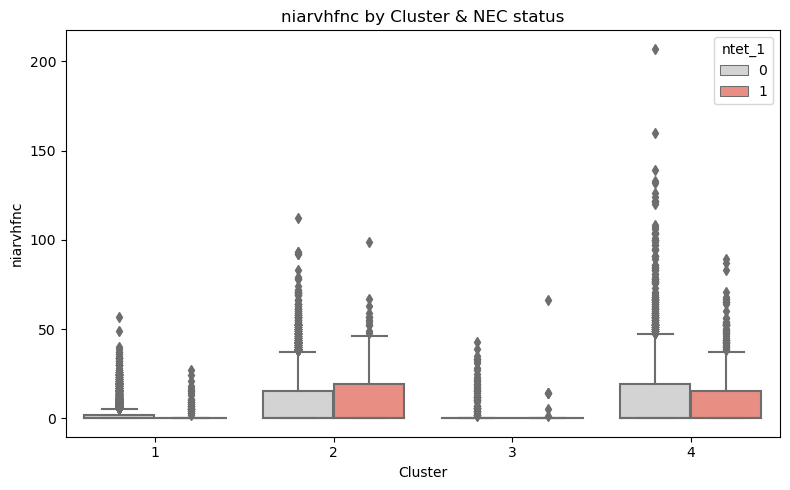

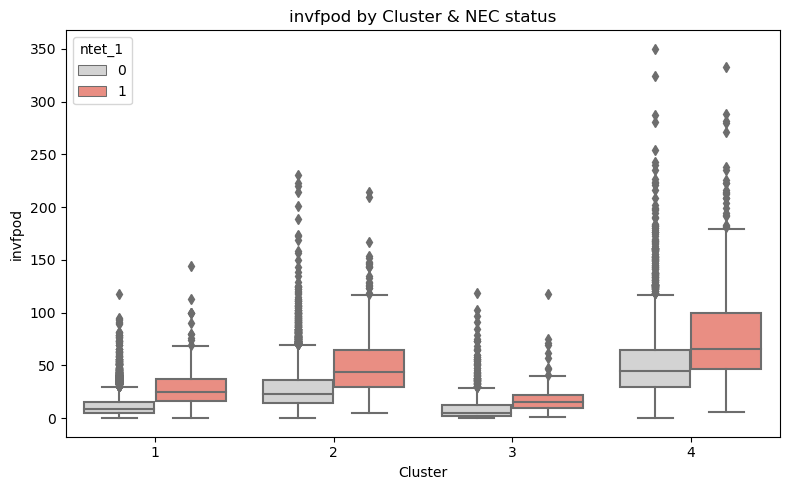

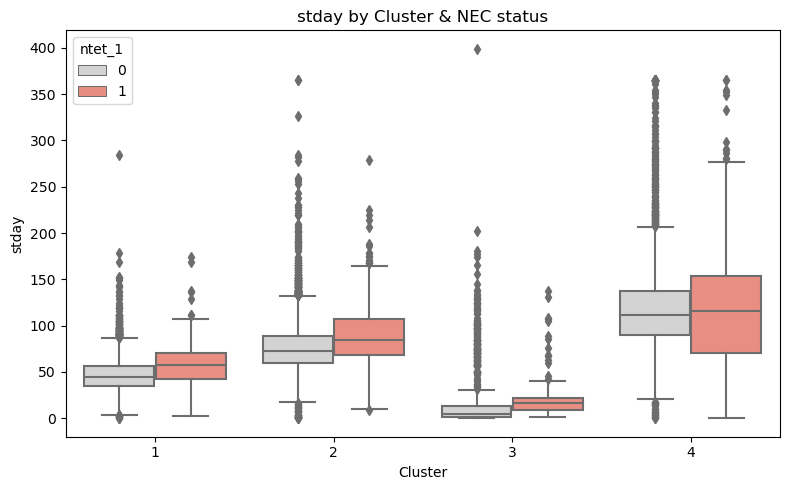

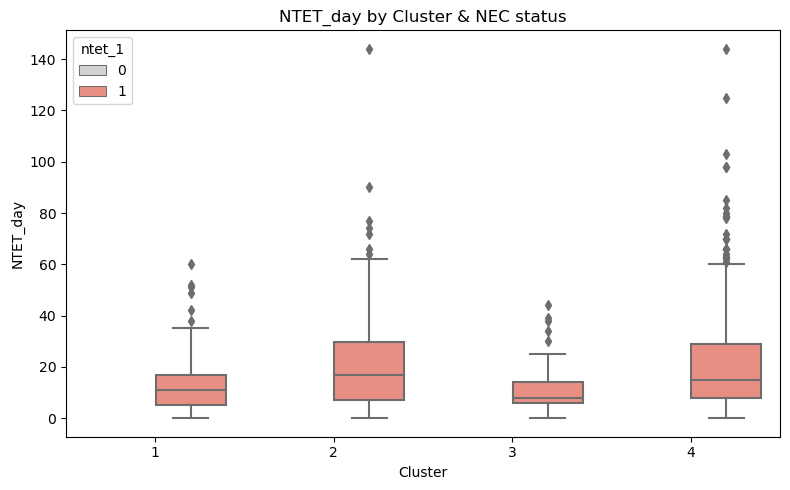

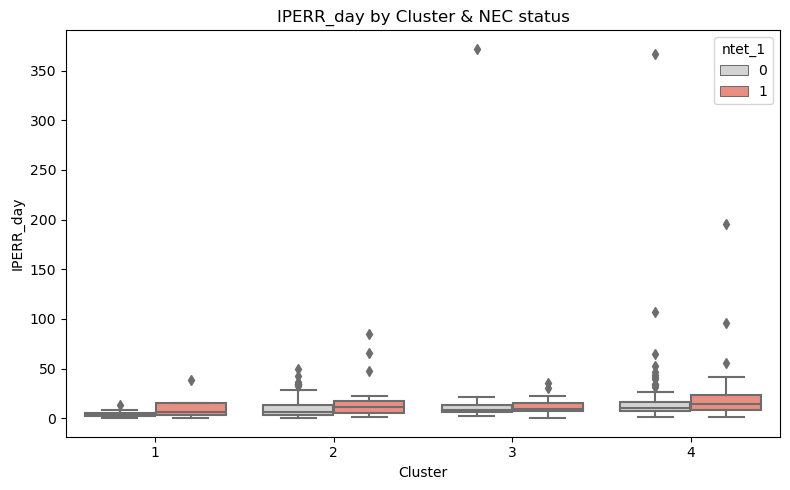

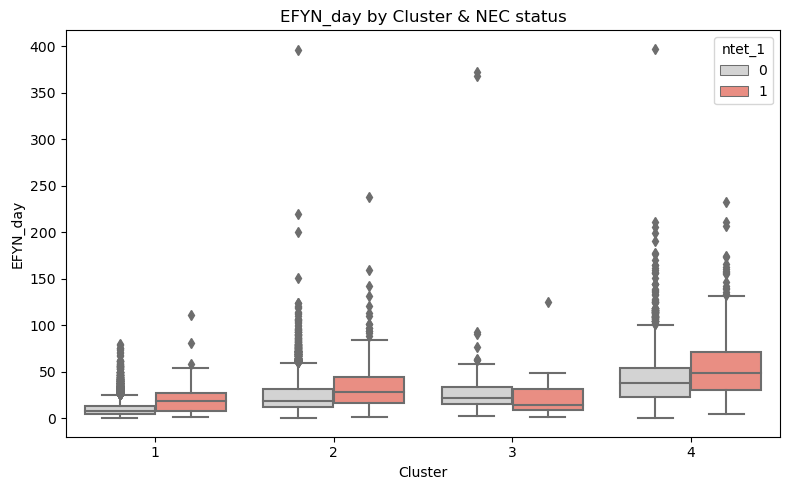

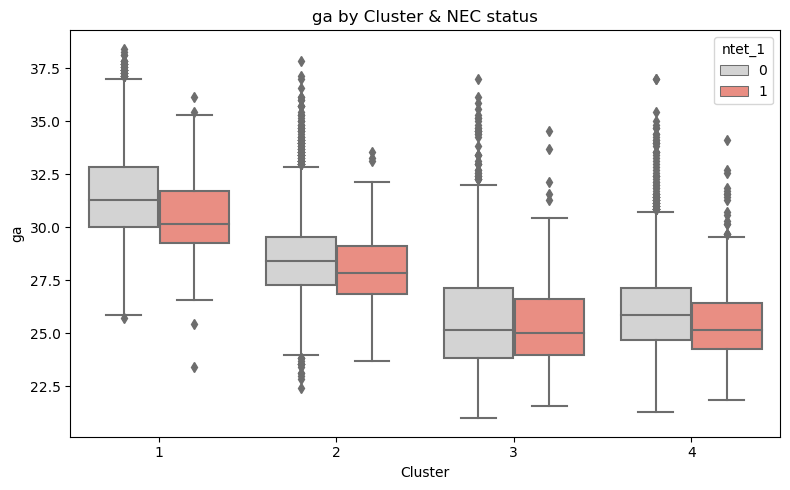

ValueError: cannot insert ntet_1, already exists

In [28]:
df_plot = df_scd.copy()
df_plot['Cluster_Labels'] = cluster_labels

binary_cols = [
    col for col in df_scd.columns
    if set(df_scd[col].dropna().unique()).issubset({0, 1})
]
continuous_cols = [
    col for col in df_scd.columns
    if col not in binary_cols
]

# 2) 연속형 변수: 한 피처당 모든 클러스터·NEC 상태 박스플롯
for feat in continuous_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x='Cluster_Labels',
        y=feat,
        hue='ntet_1',
        data=df_plot,
        palette={0:'lightgrey', 1:'salmon'}
    )
    plt.title(f'{feat} by Cluster & NEC status')
    plt.xlabel('Cluster')
    plt.ylabel(feat)
    plt.legend(title='ntet_1')
    plt.tight_layout()
    plt.show()

# 3) 이진형 변수: 한 피처당 모든 클러스터·NEC 상태 바플롯
prop = (
    df_plot
    .groupby(['Cluster_Labels','ntet_1'])[binary_cols]
    .mean()
    .reset_index()
    .melt(id_vars=['Cluster_Labels','ntet_1'],
          var_name='feature', value_name='rate')
)
for feat in binary_cols:
    df_prop = prop[prop['feature']==feat]
    plt.figure(figsize=(6,4))
    sns.barplot(
        x='Cluster_Labels',
        y='rate',
        hue='ntet_1',
        data=df_prop,
        palette={0:'lightgrey', 1:'steelblue'}
    )
    plt.title(f'{feat} prevalence by Cluster & NEC status')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion')
    plt.ylim(0,1)
    plt.legend(title='ntet_1')
    plt.tight_layout()
    plt.show()

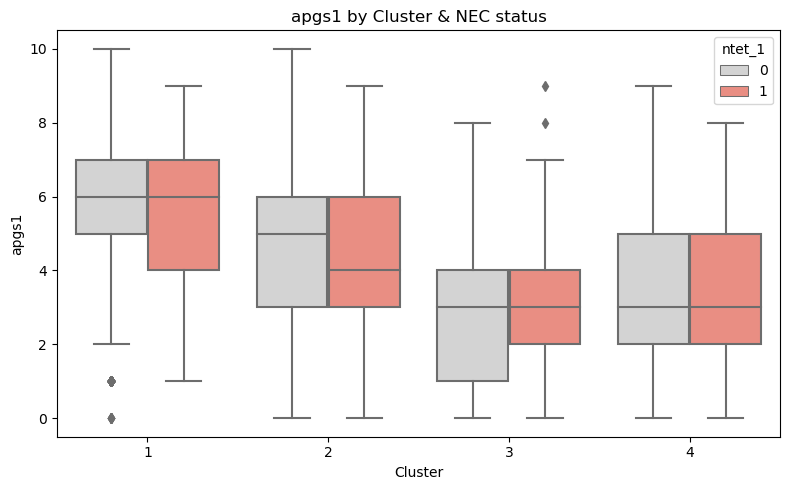

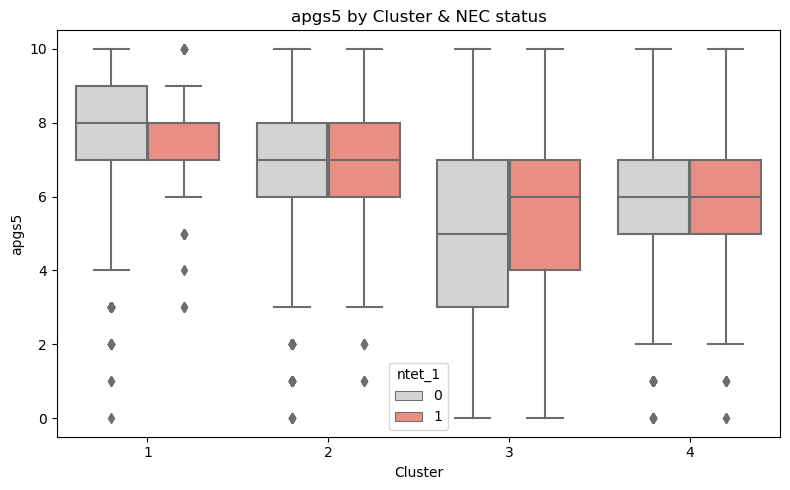

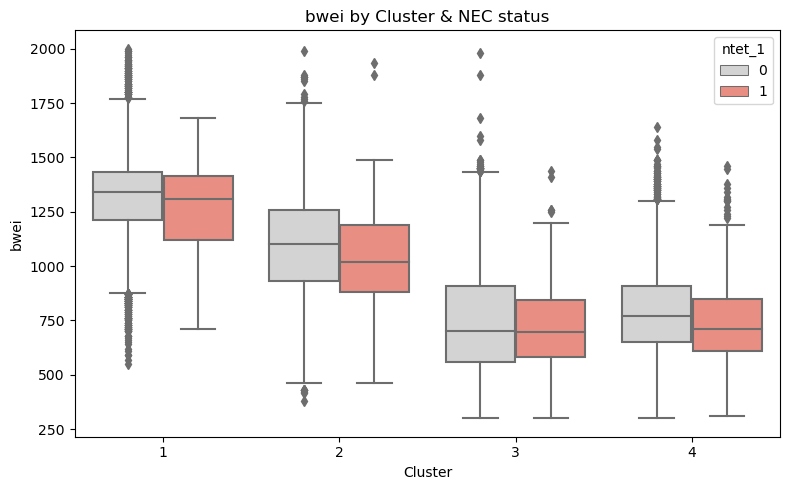

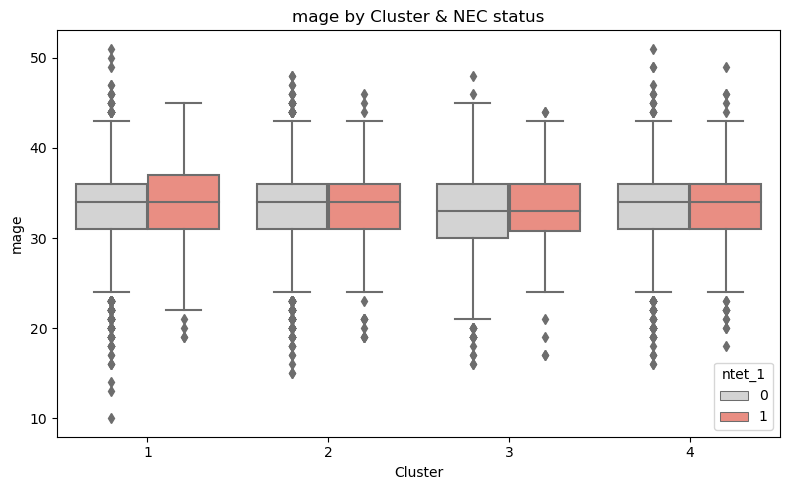

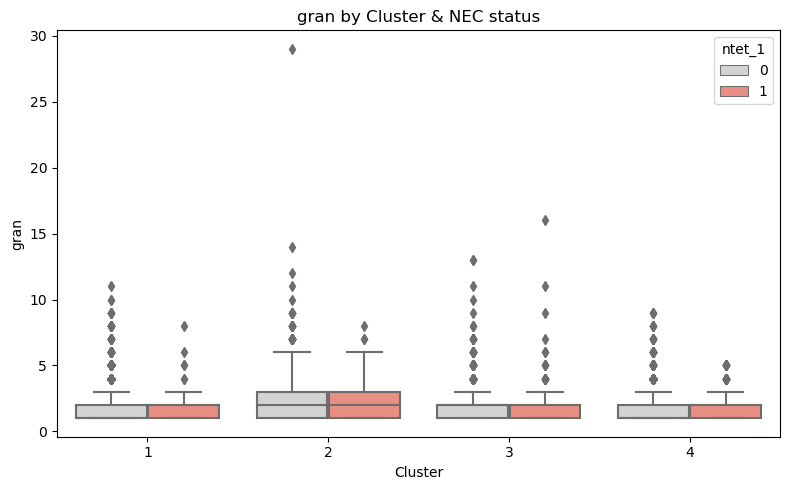

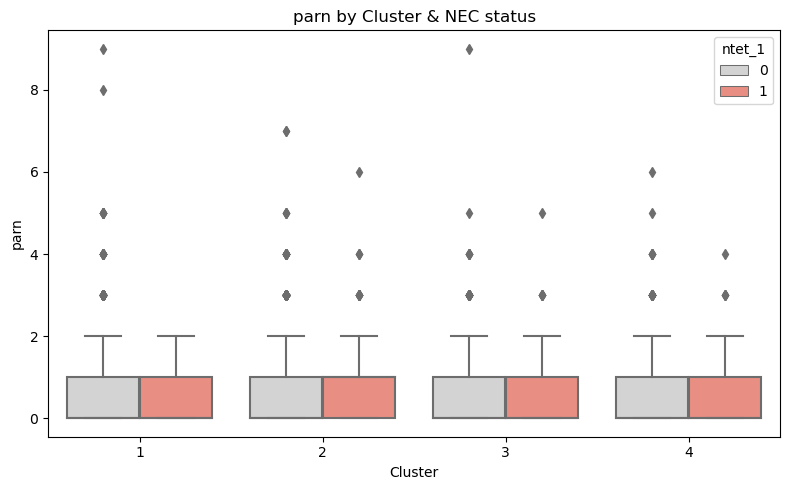

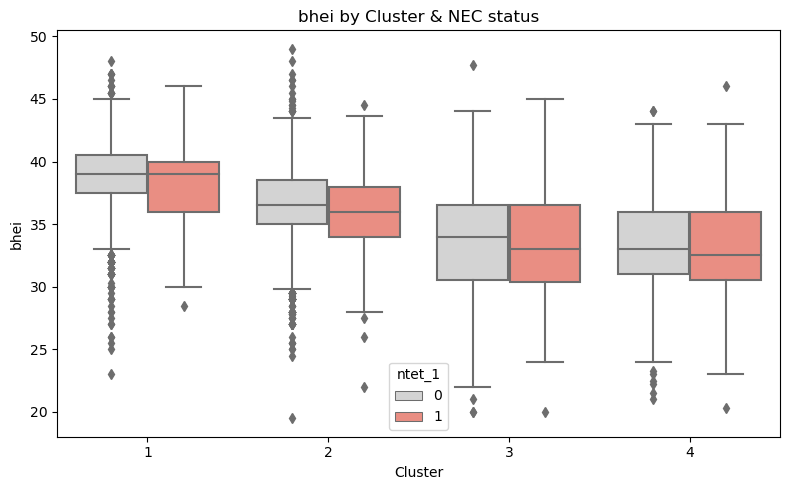

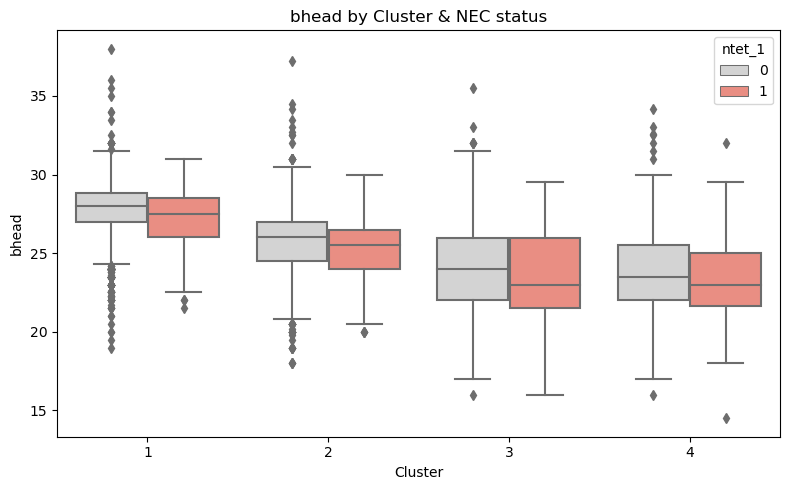

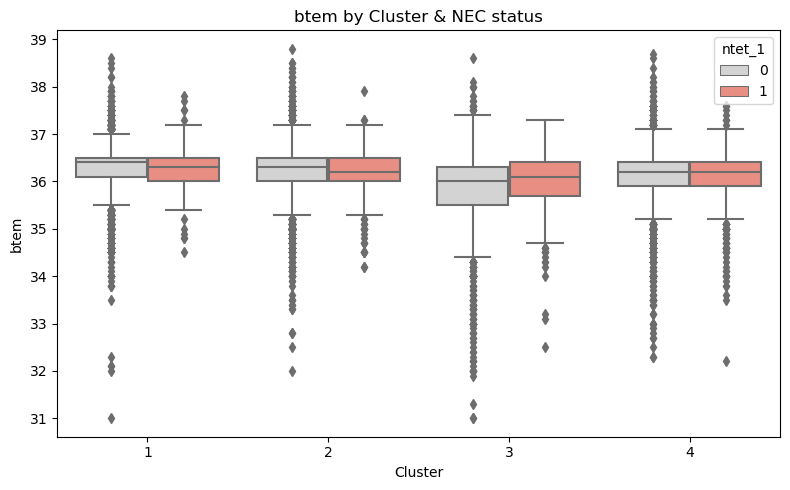

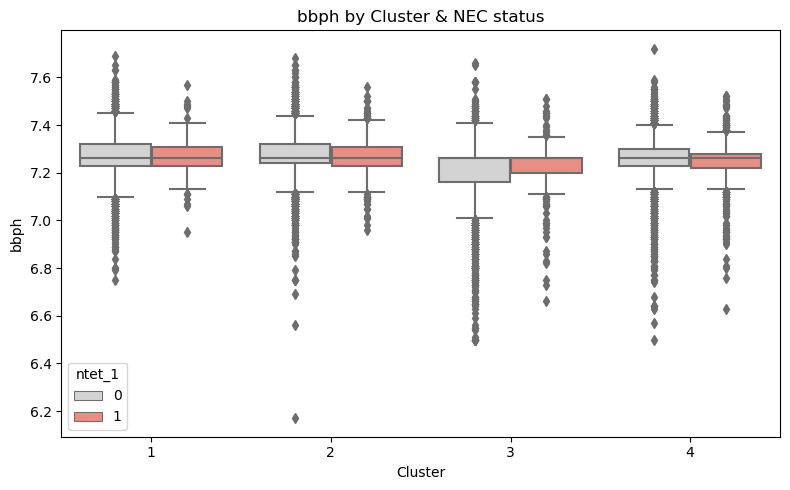

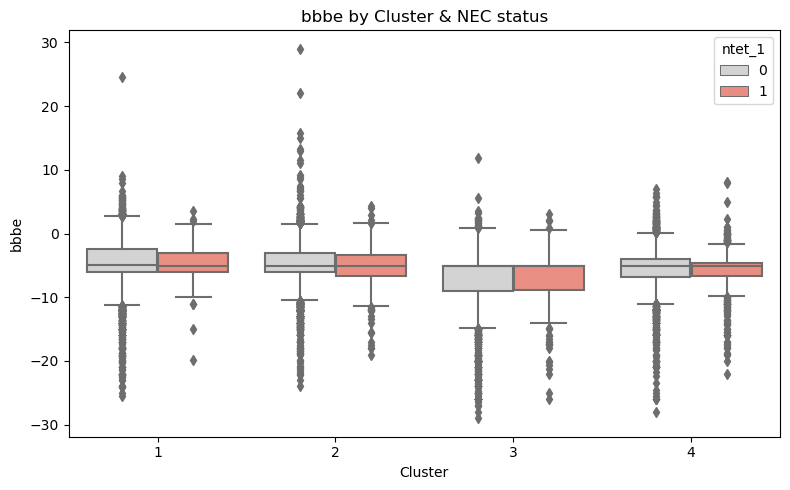

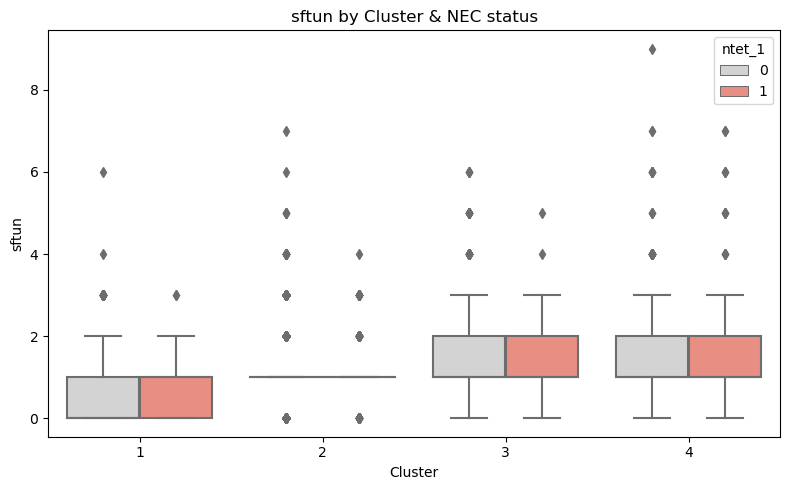

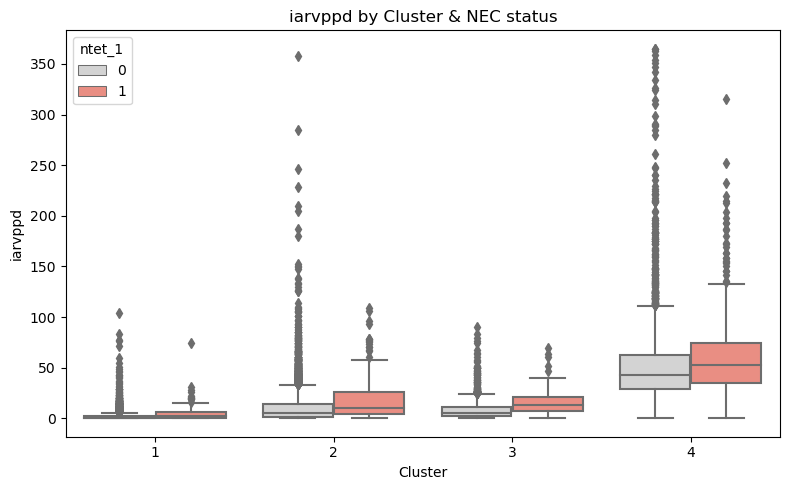

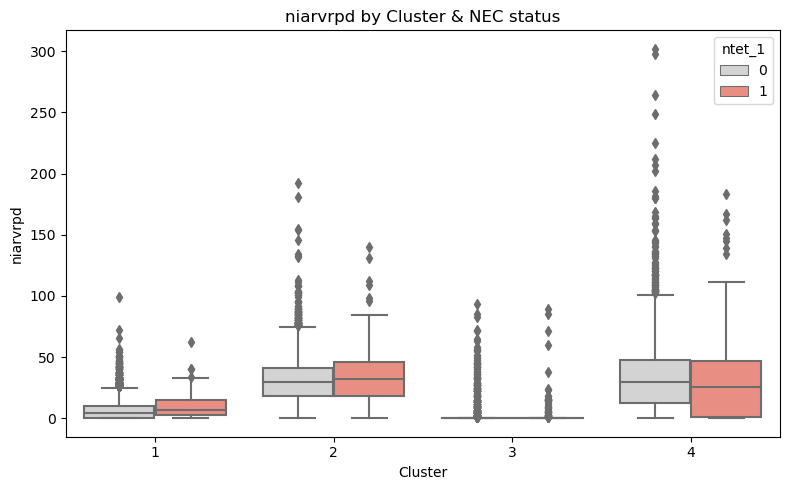

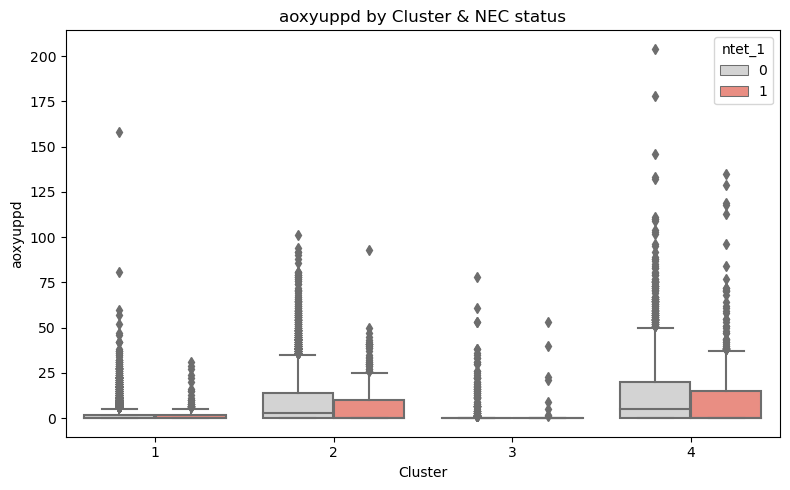

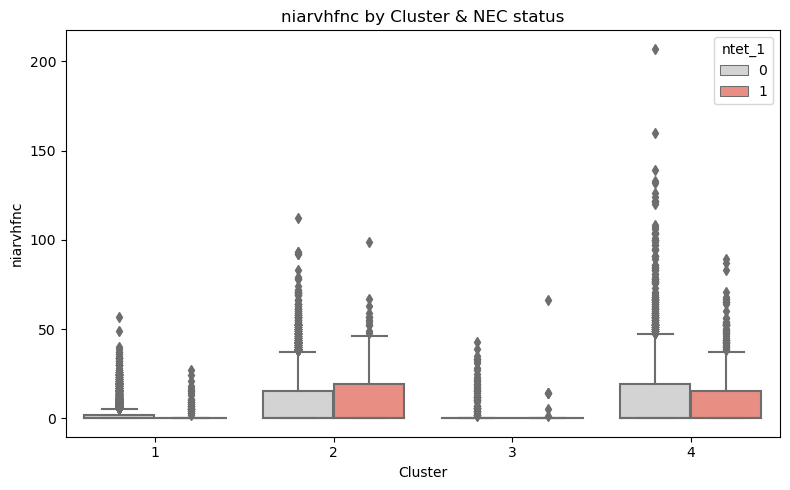

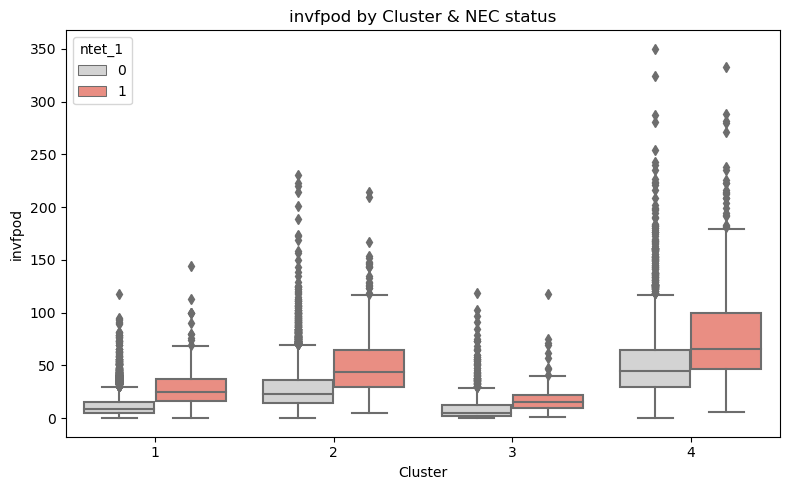

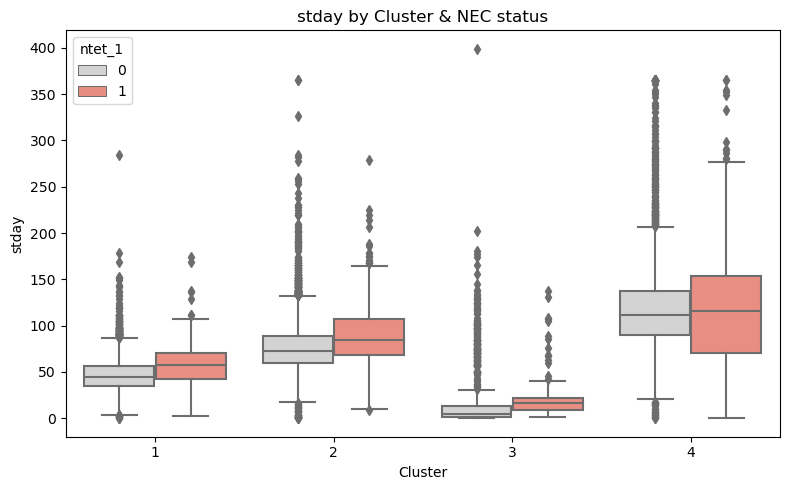

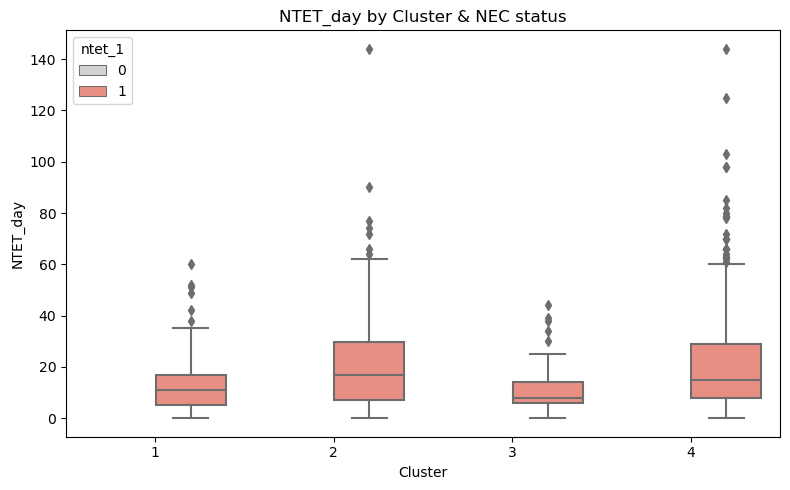

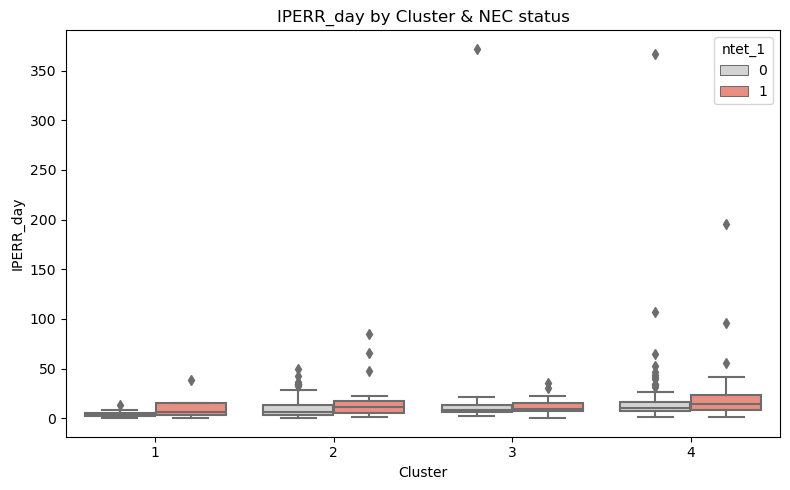

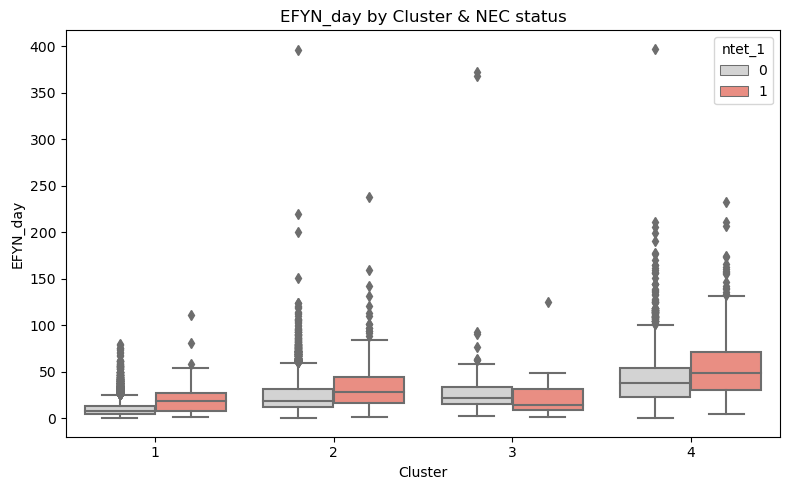

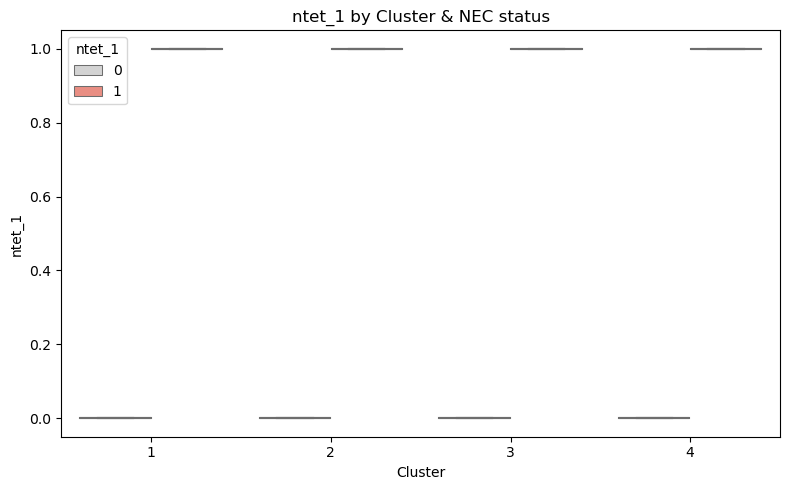

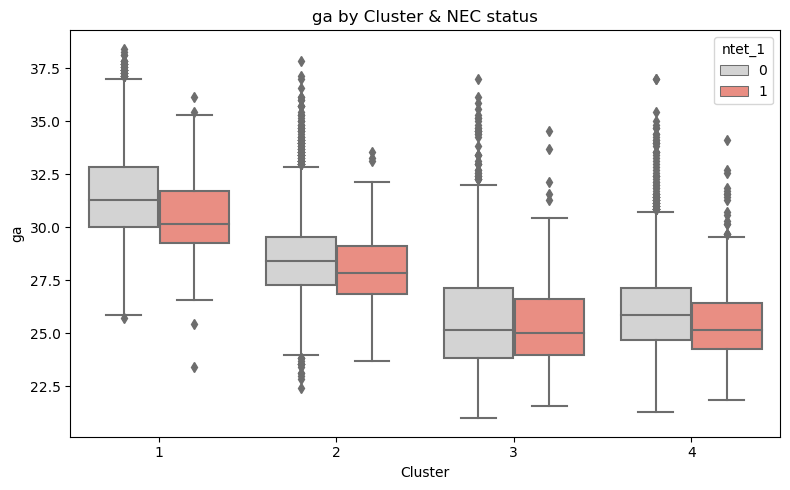

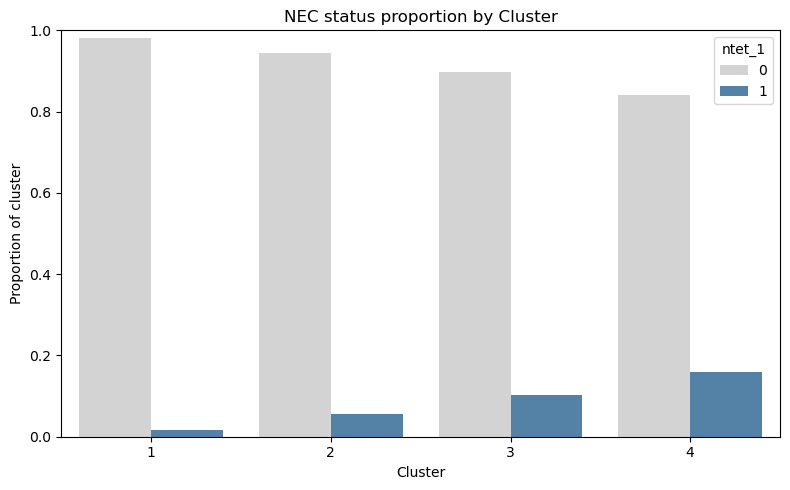

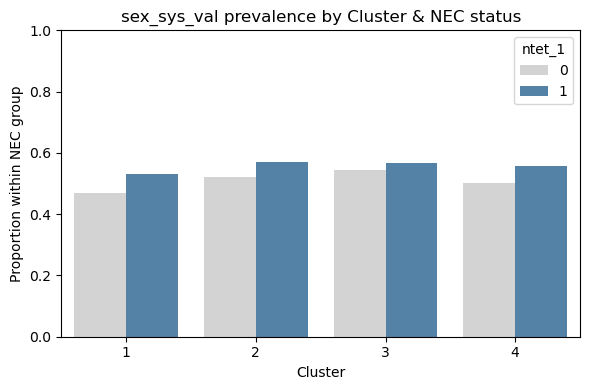

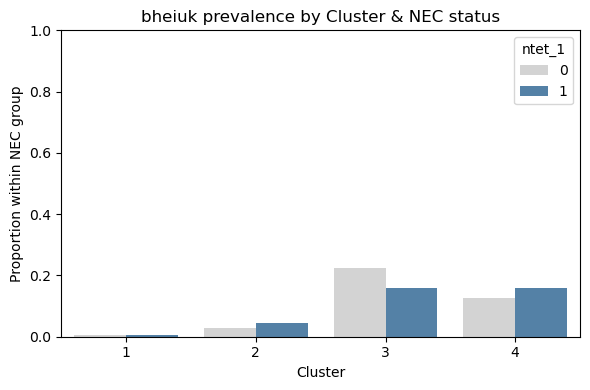

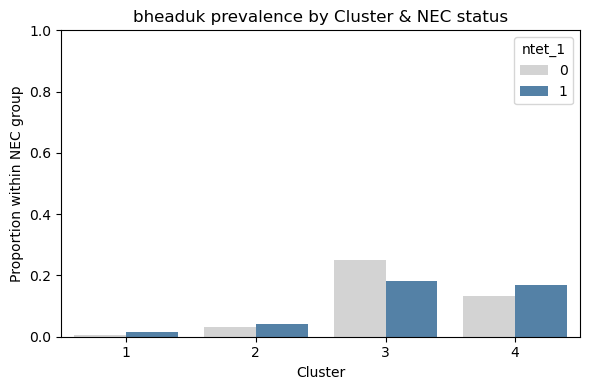

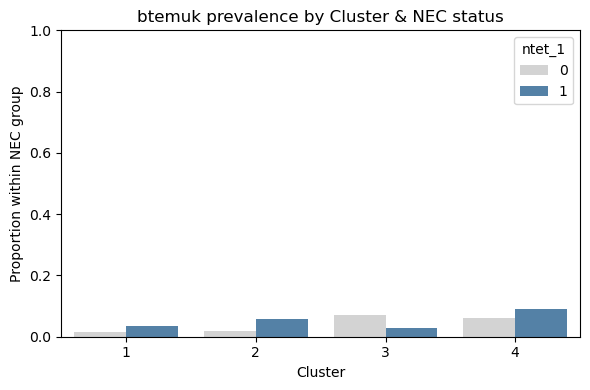

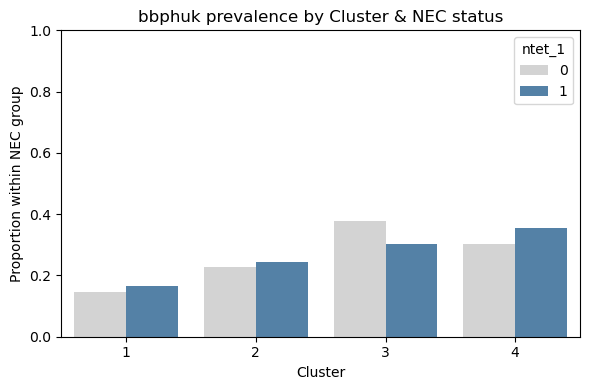

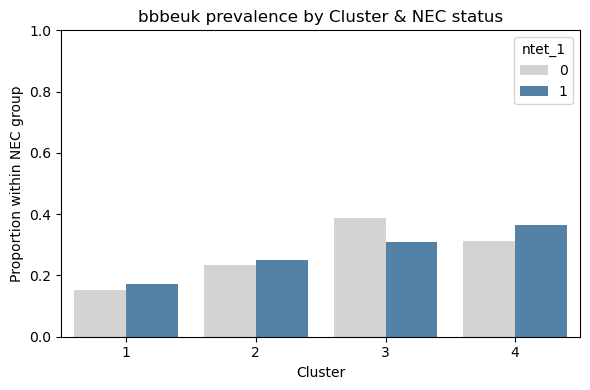

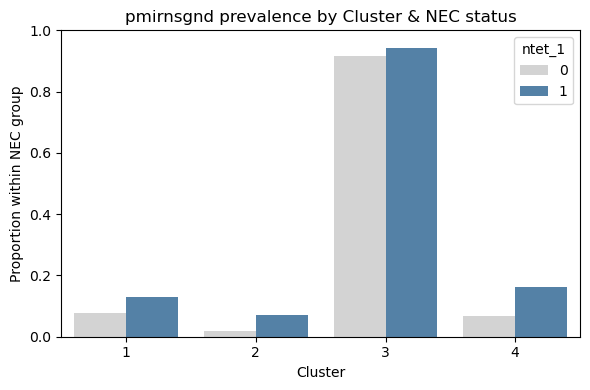

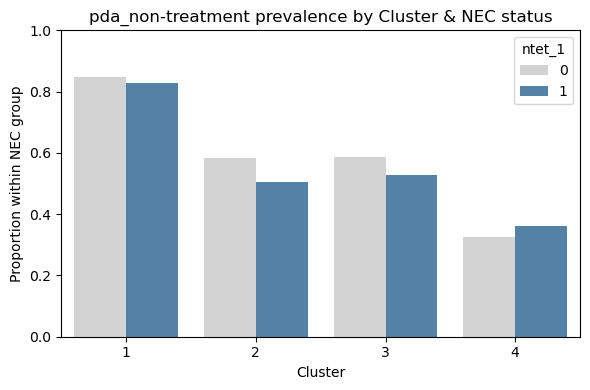

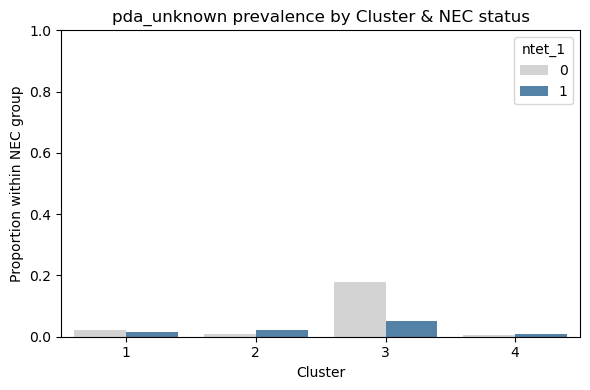

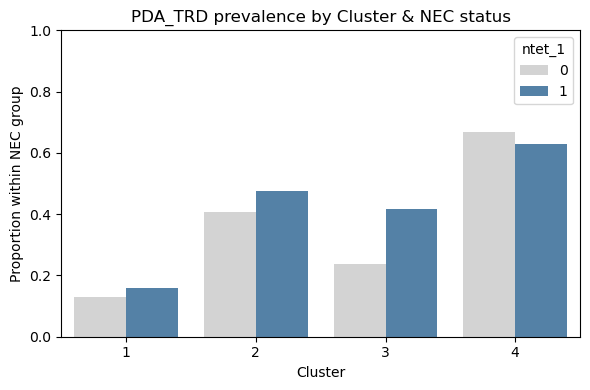

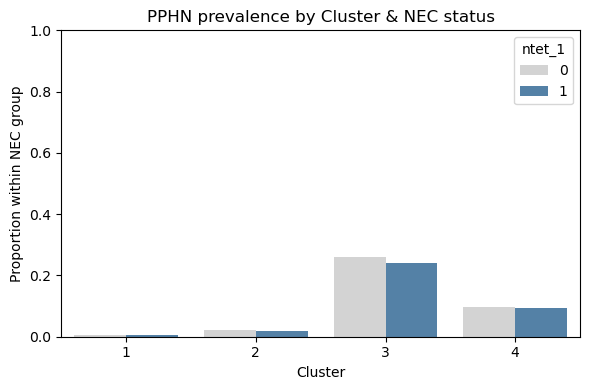

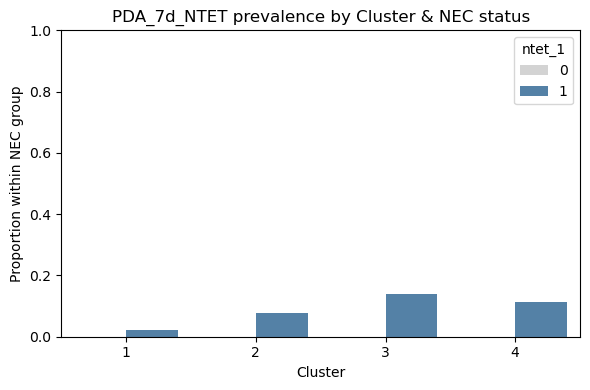

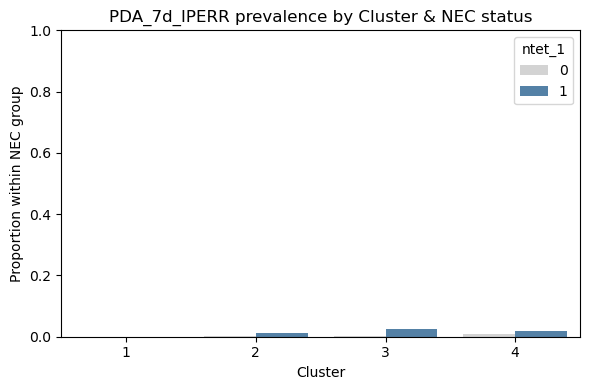

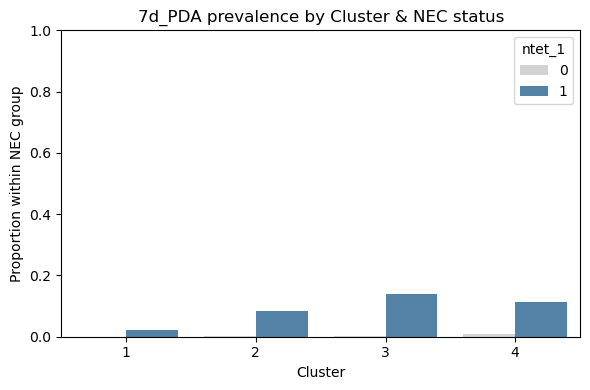

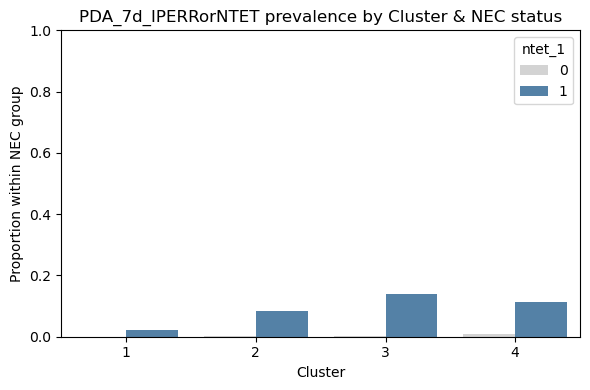

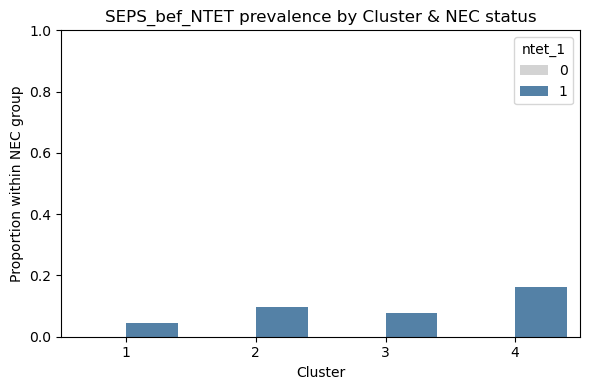

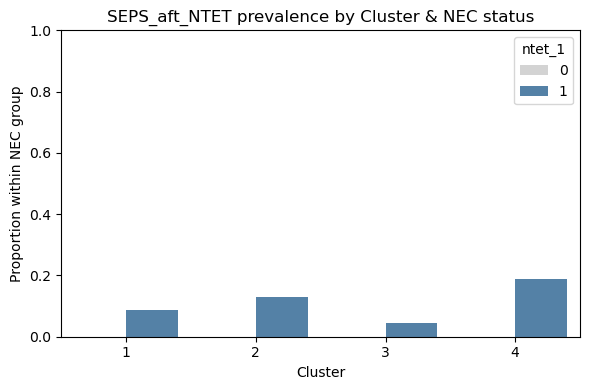

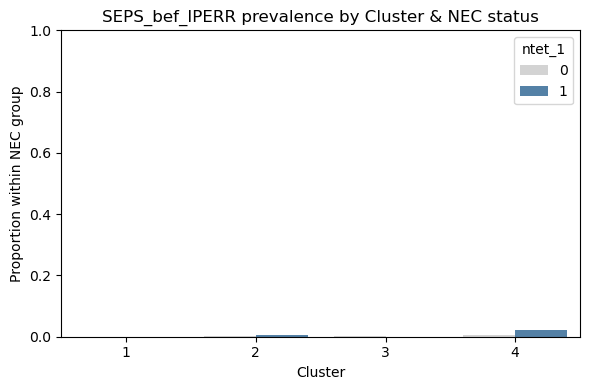

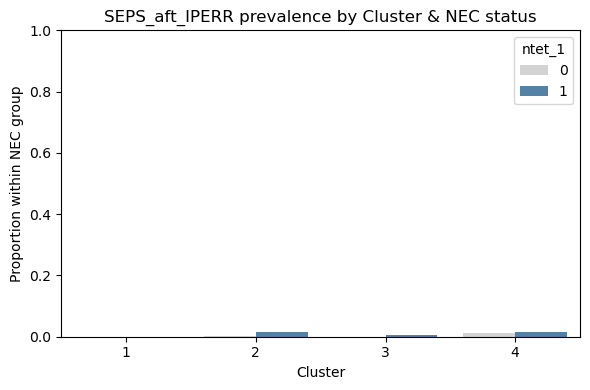

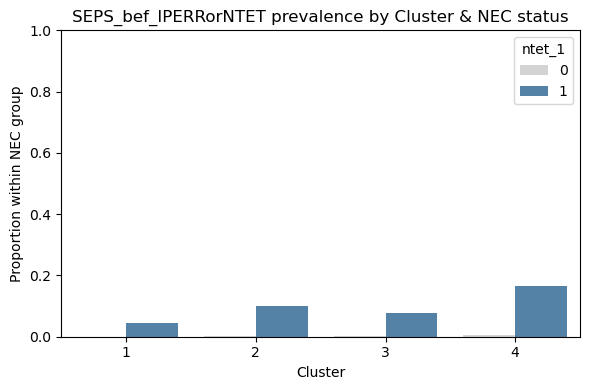

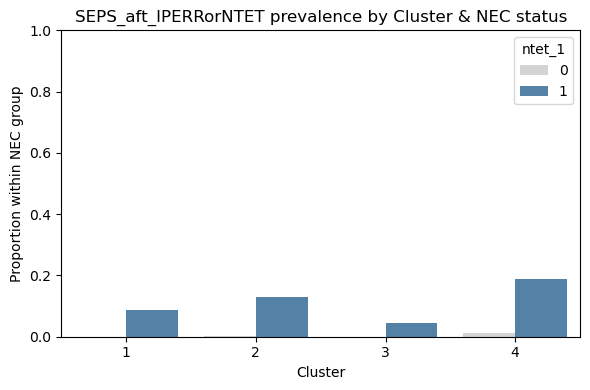

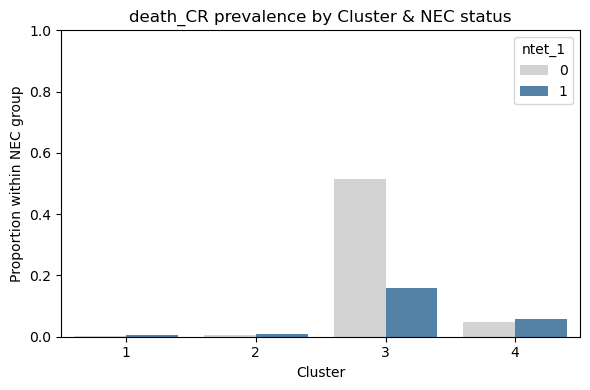

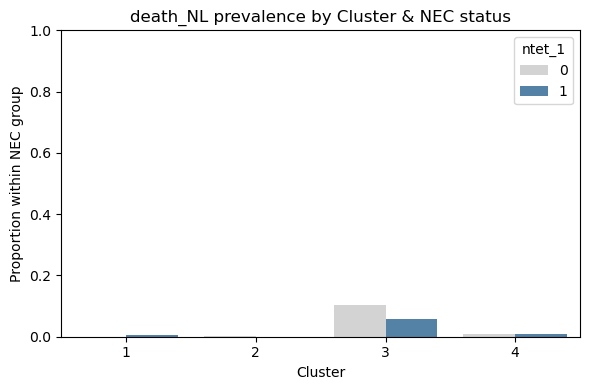

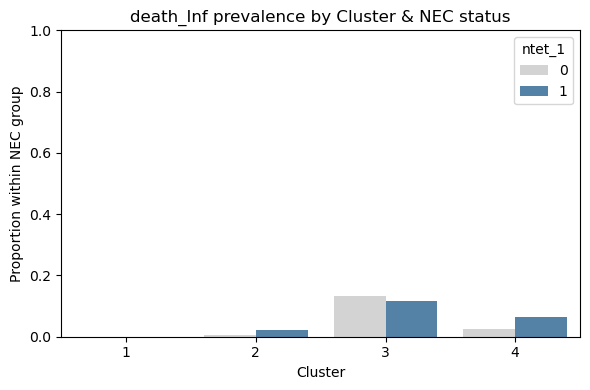

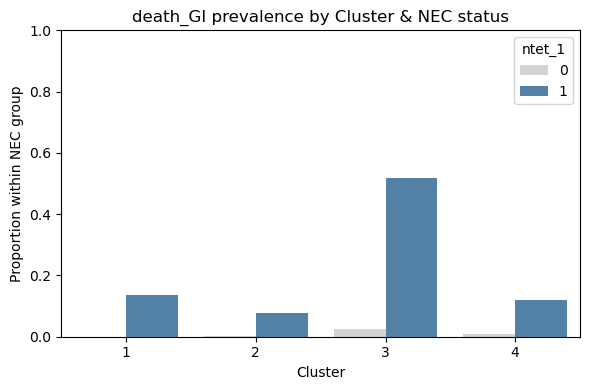

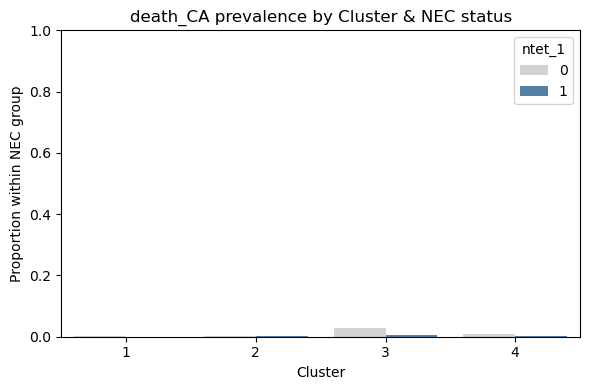

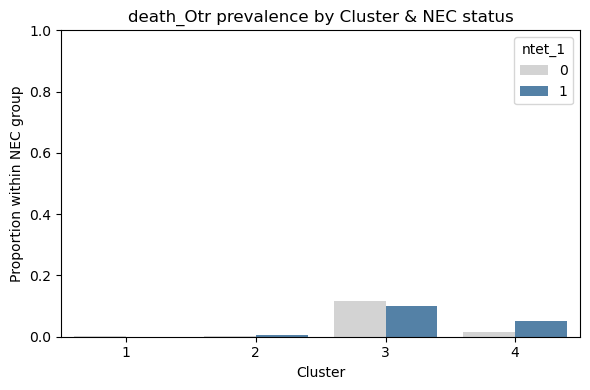

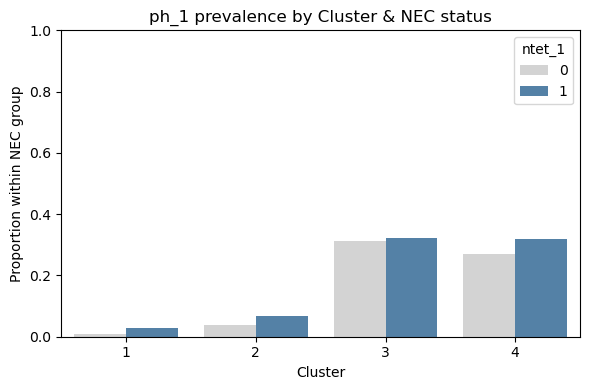

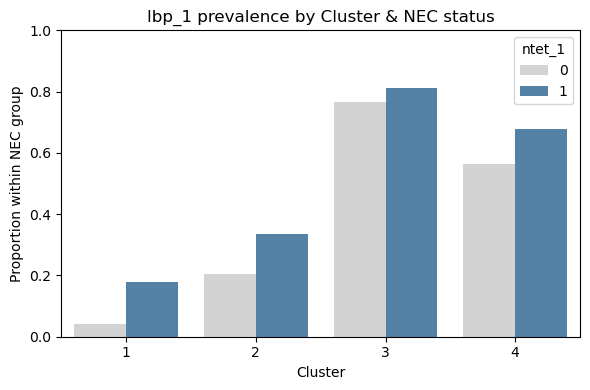

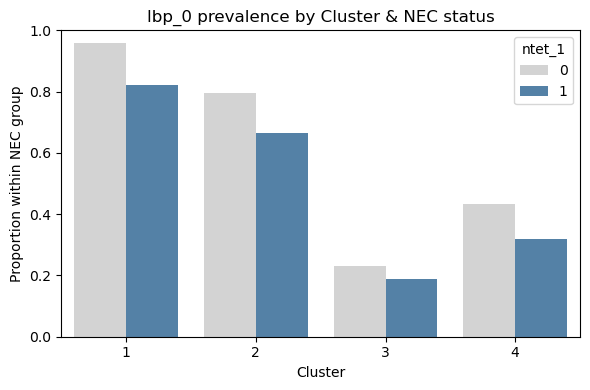

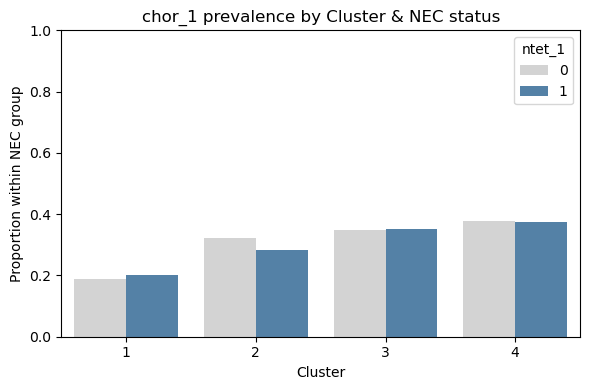

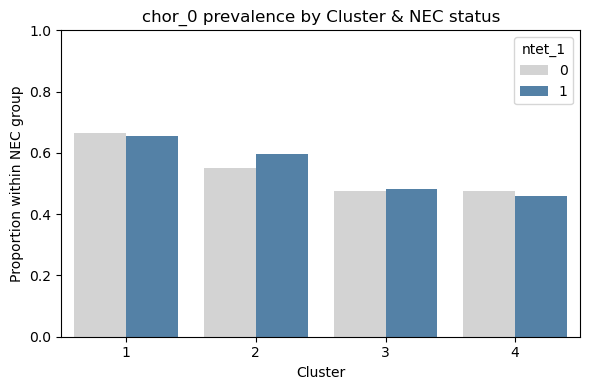

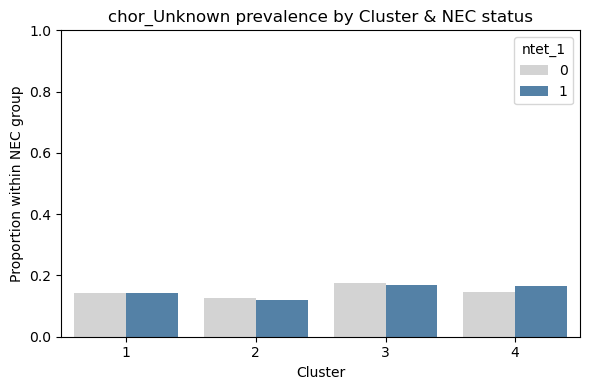

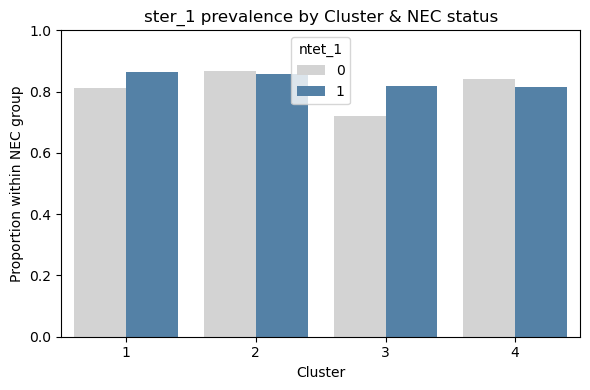

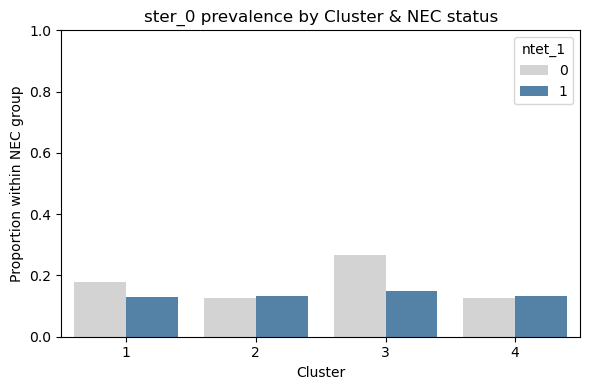

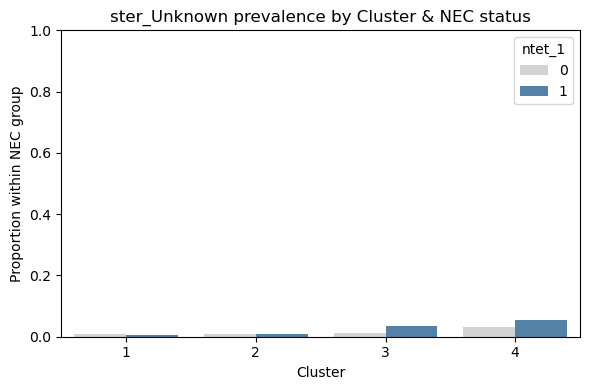

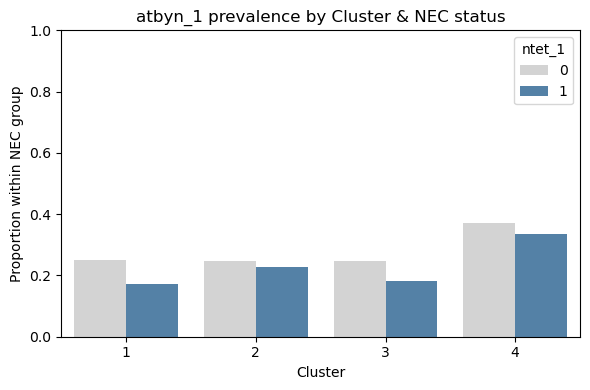

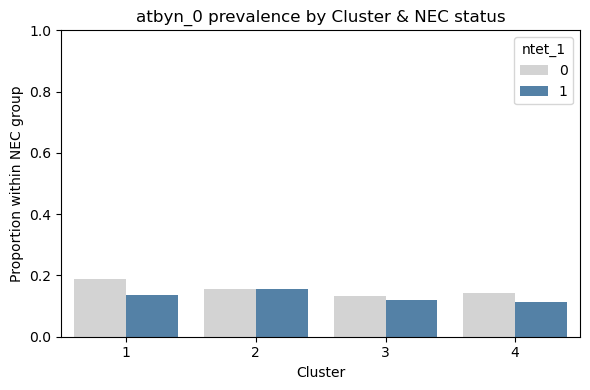

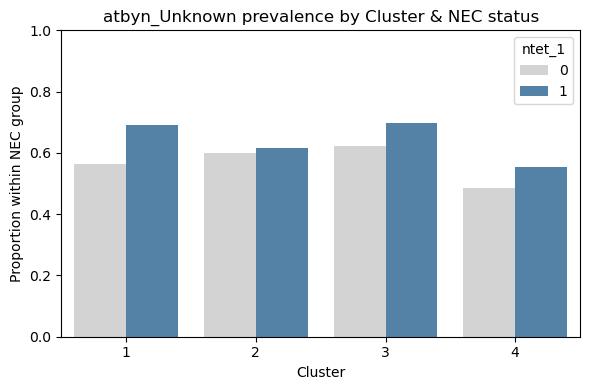

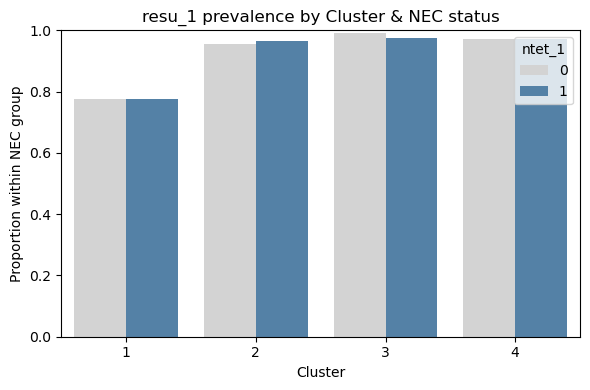

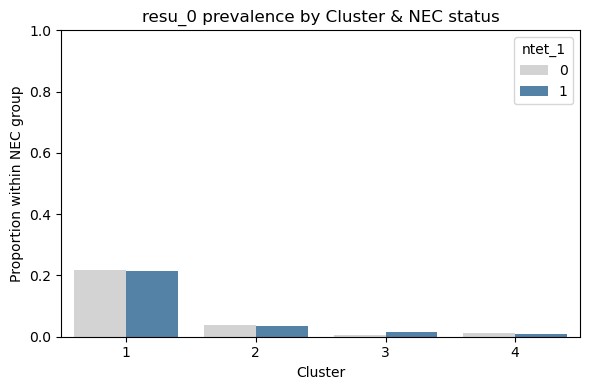

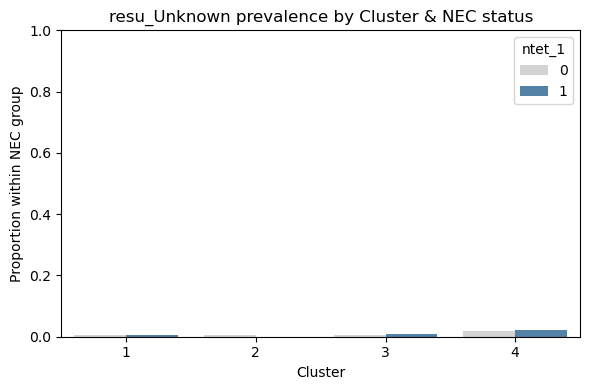

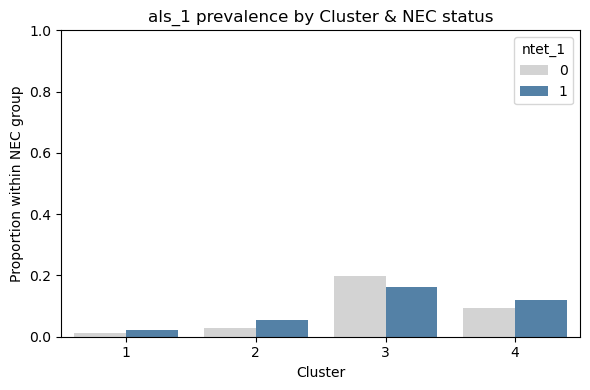

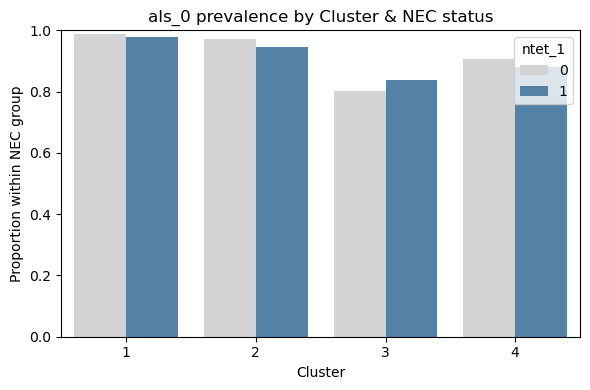

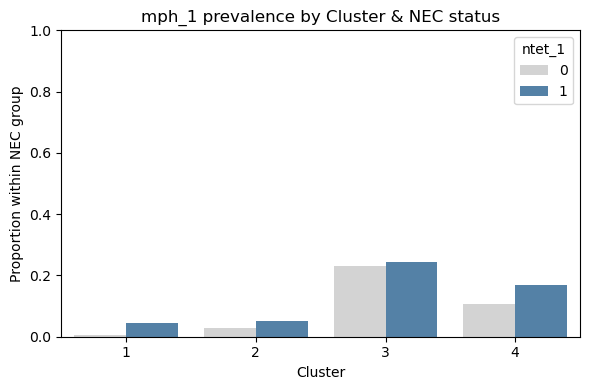

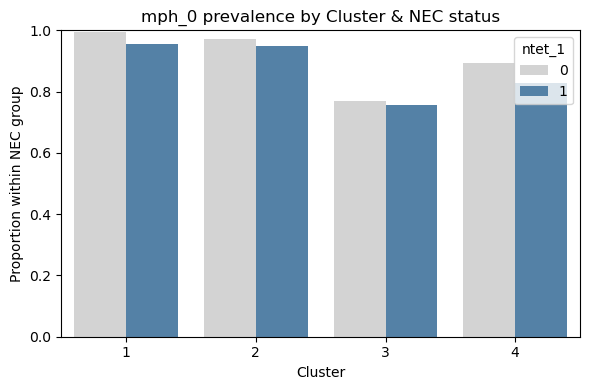

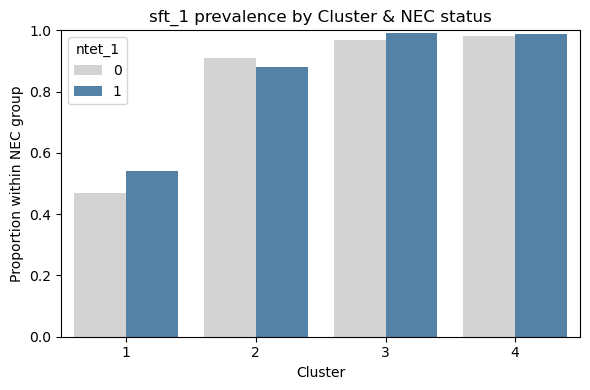

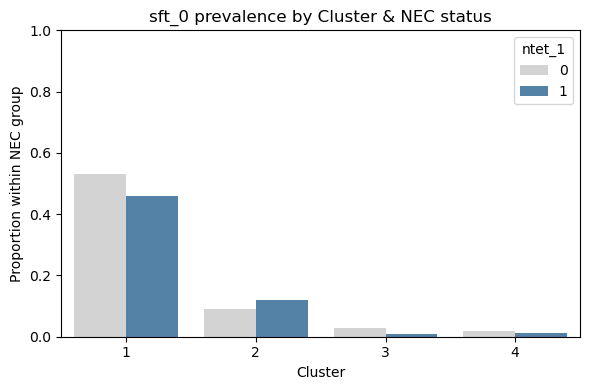

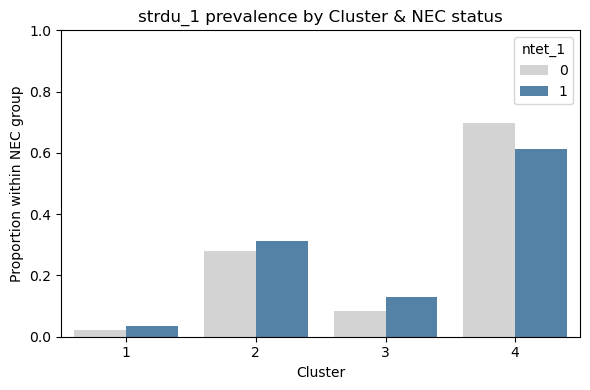

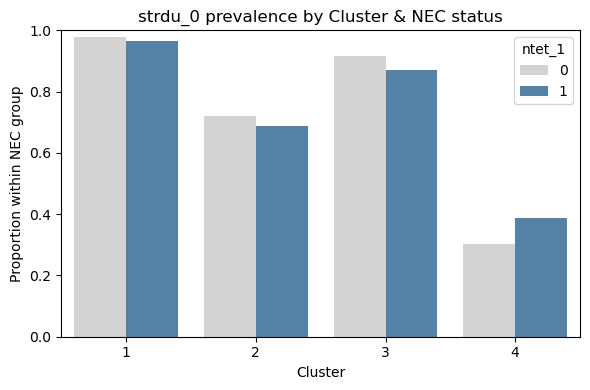

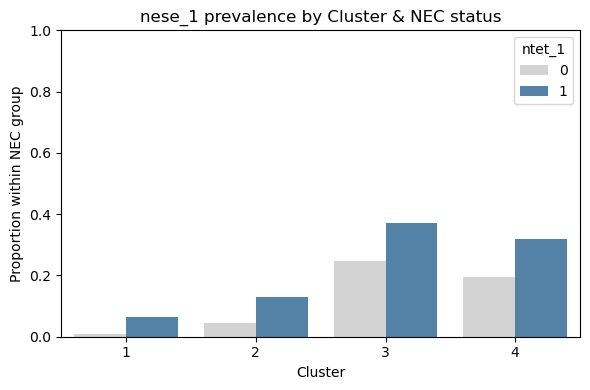

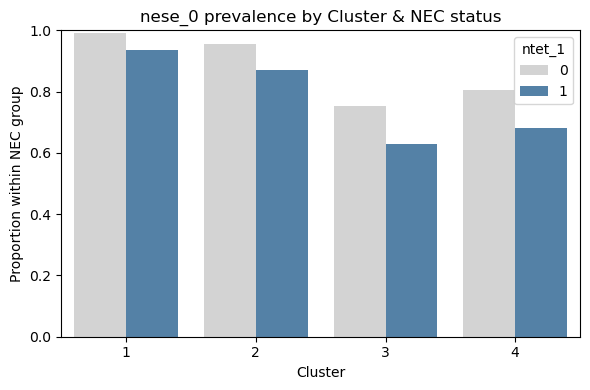

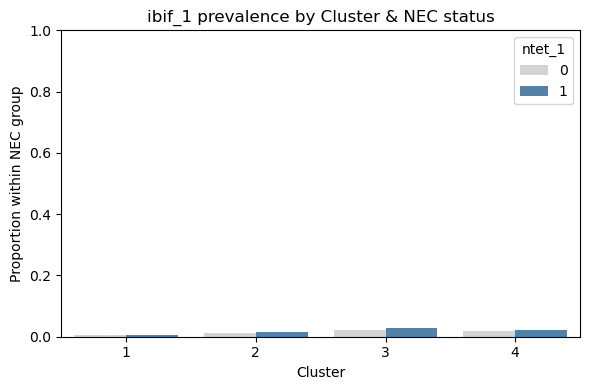

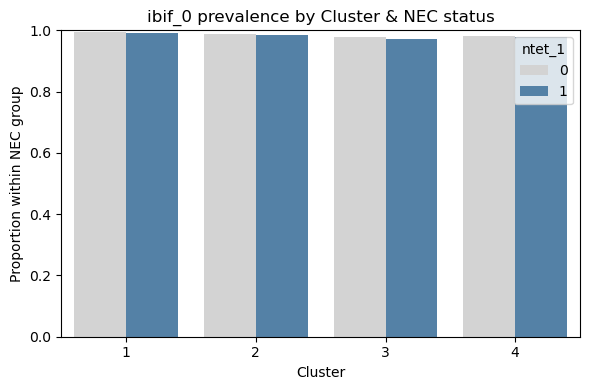

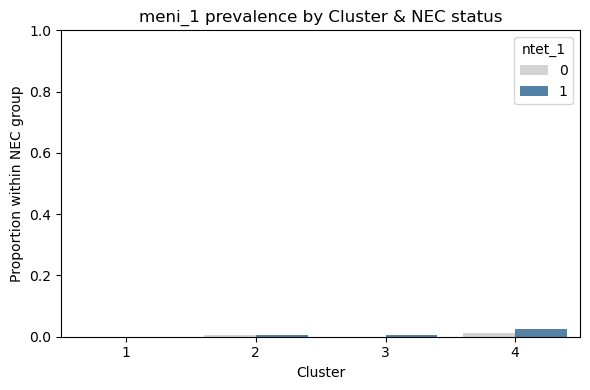

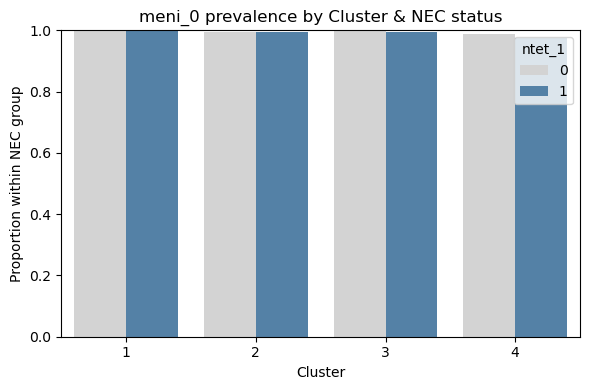

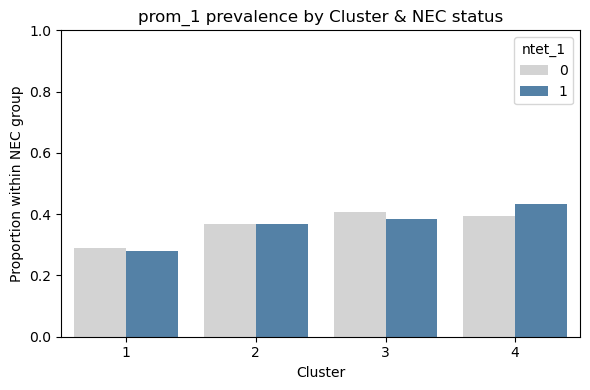

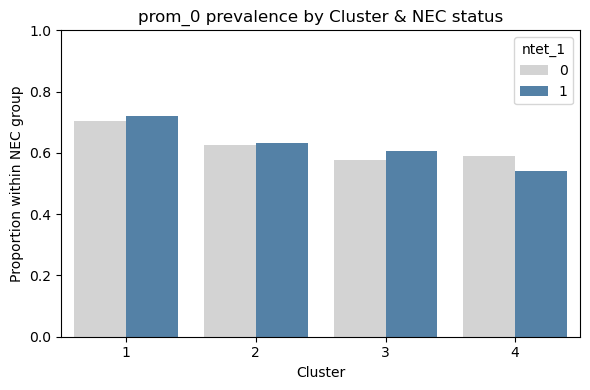

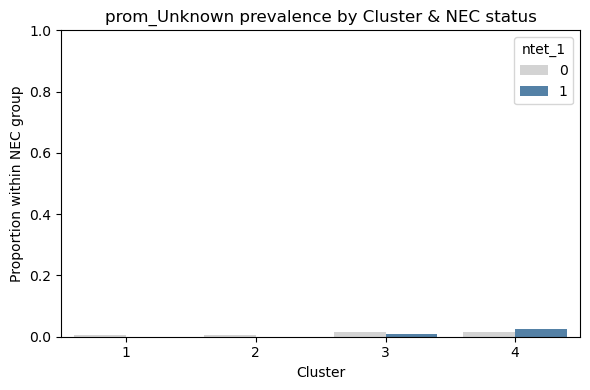

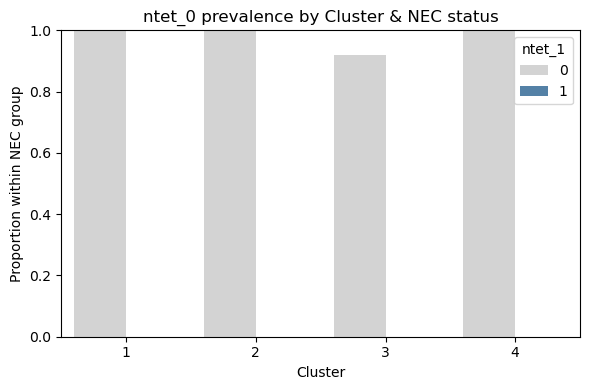

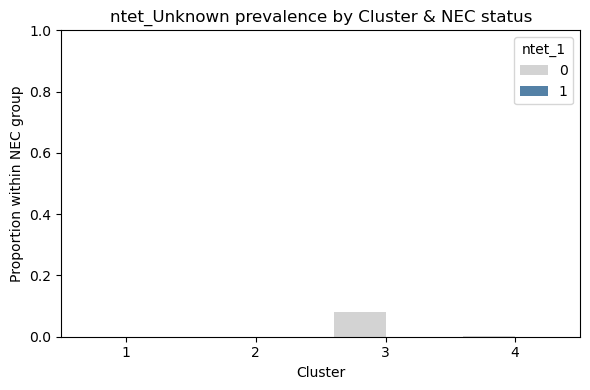

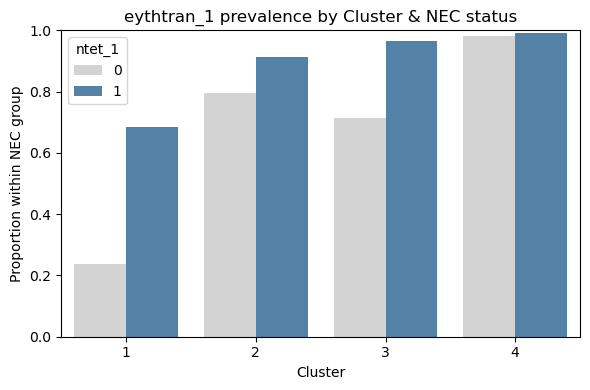

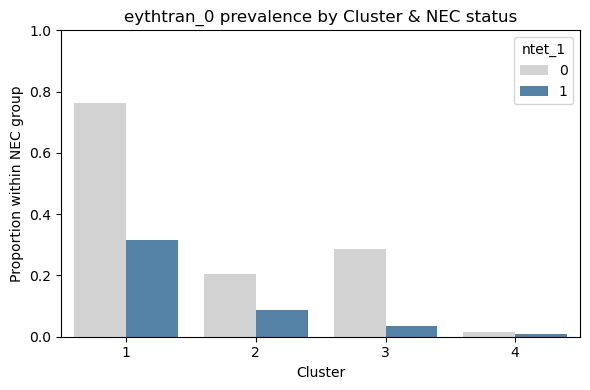

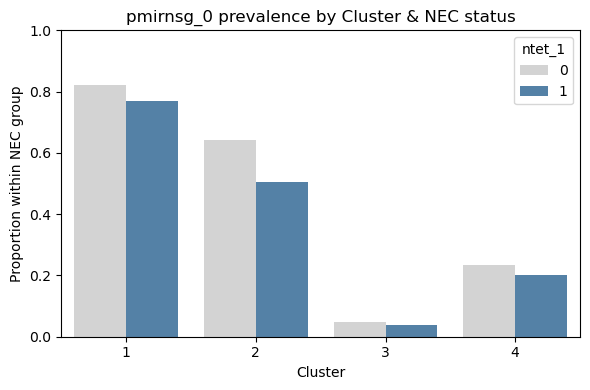

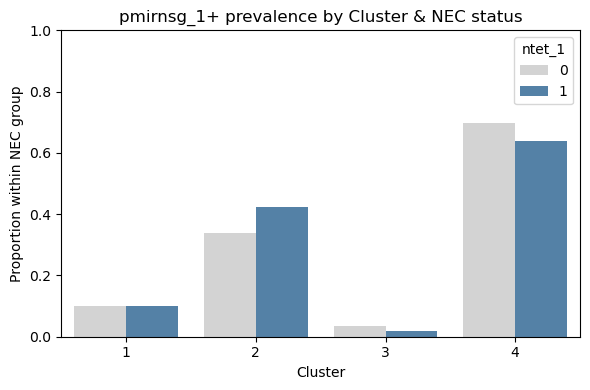

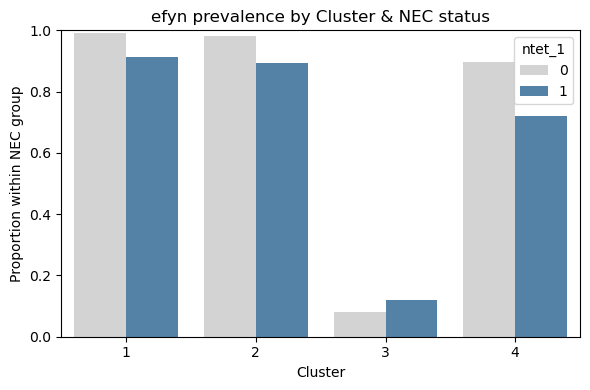

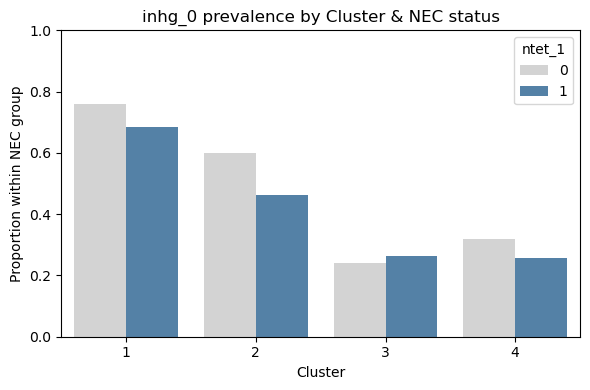

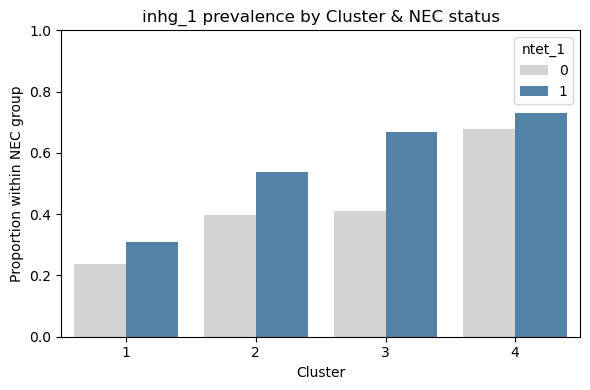

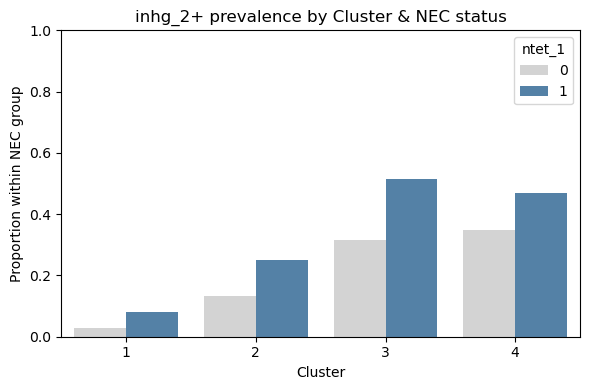

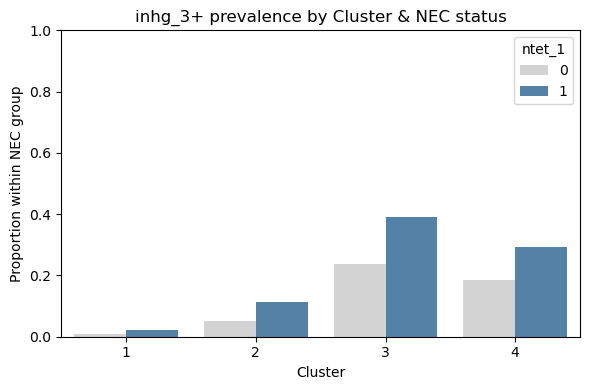

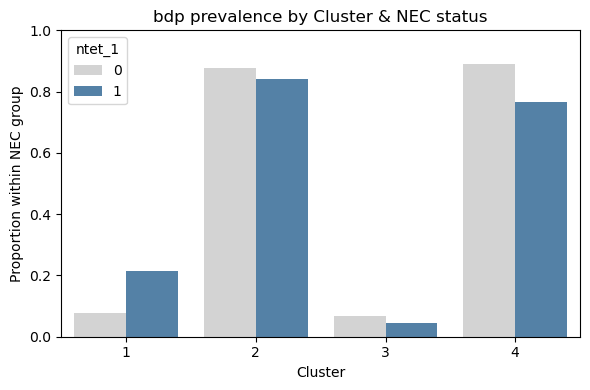

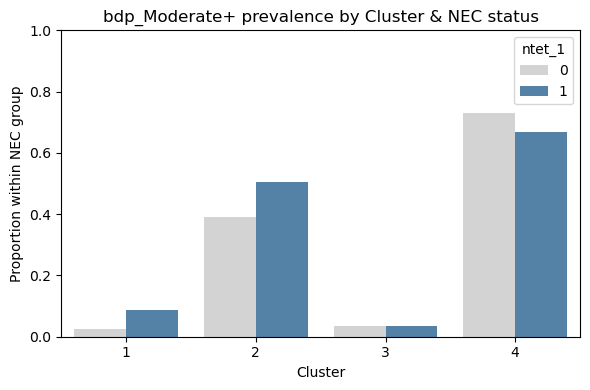

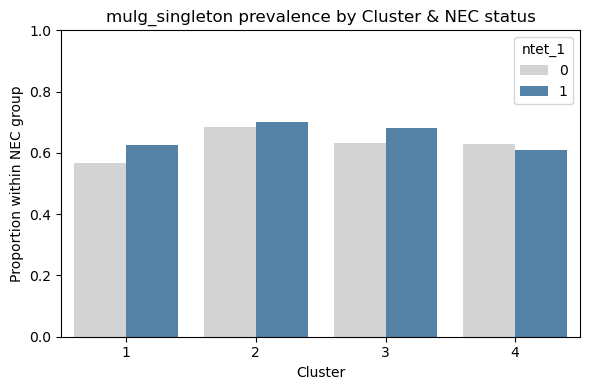

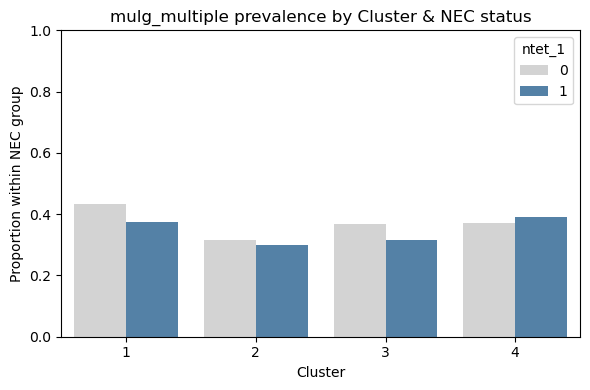

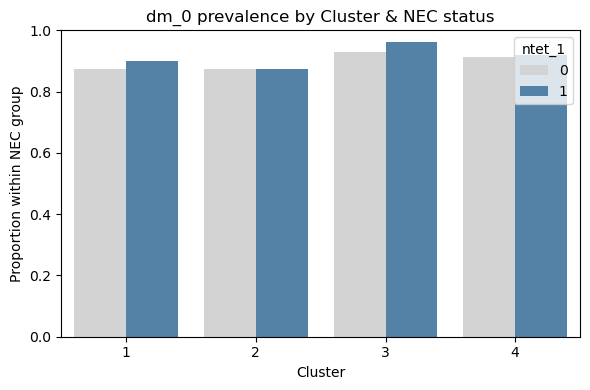

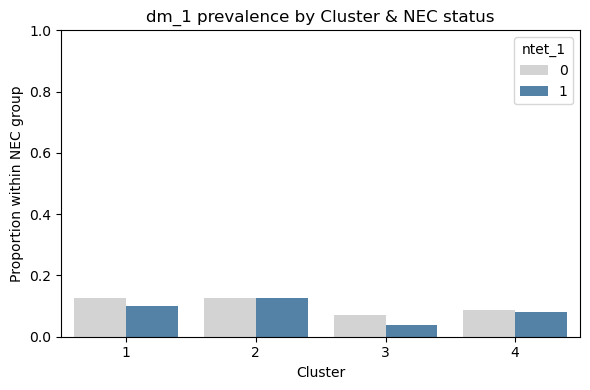

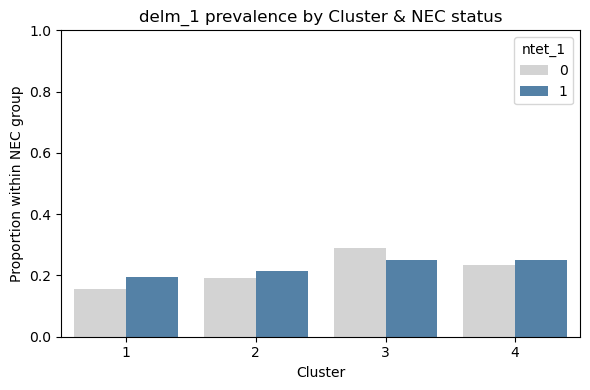

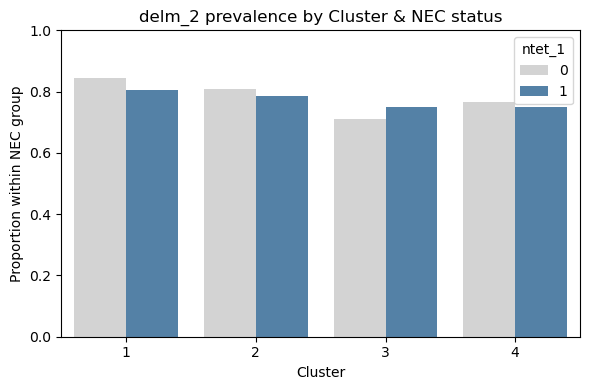

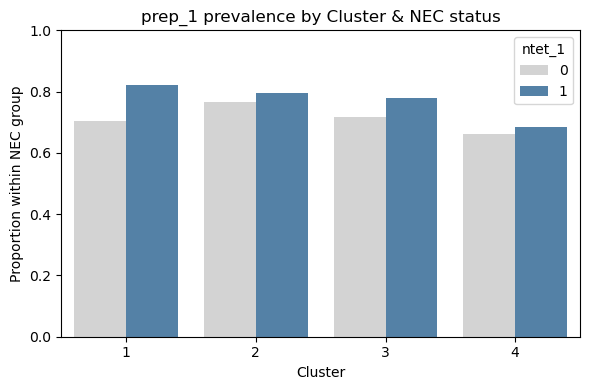

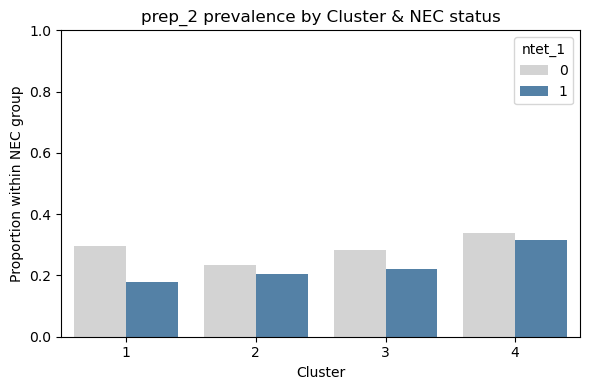

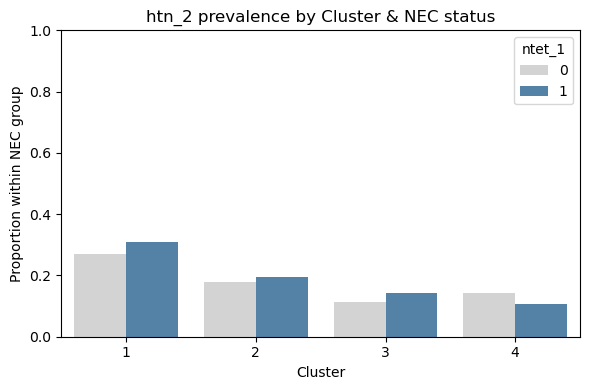

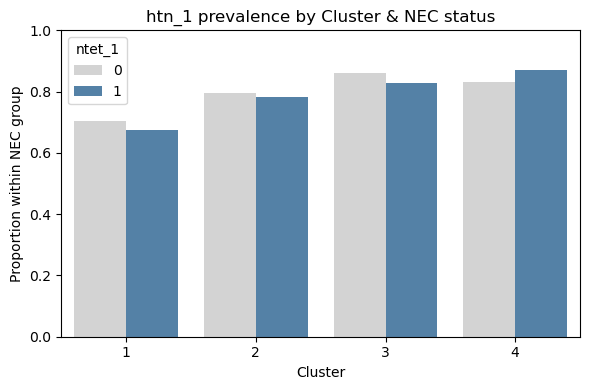

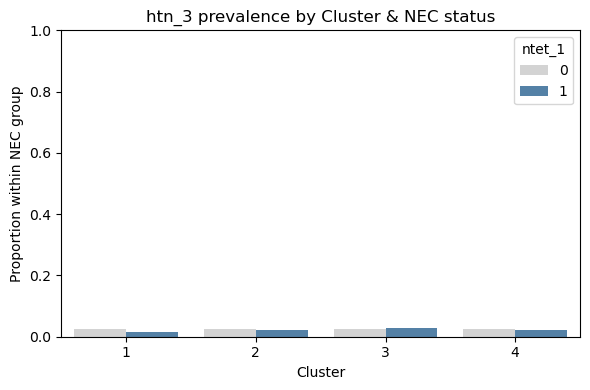

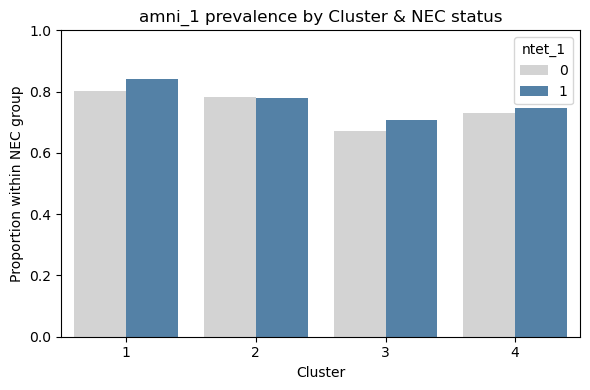

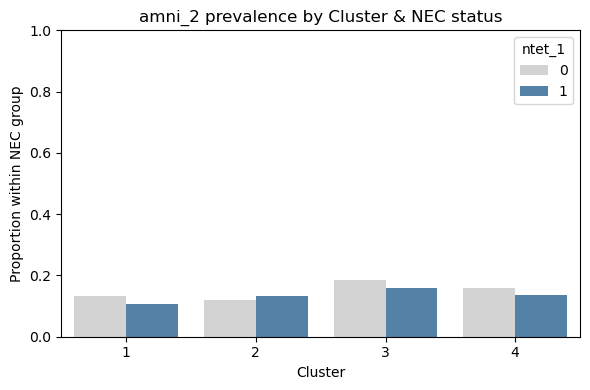

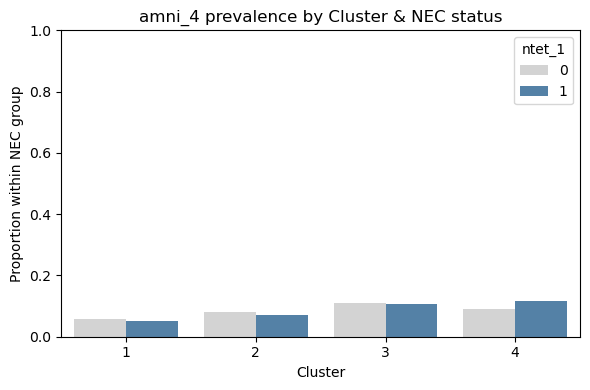

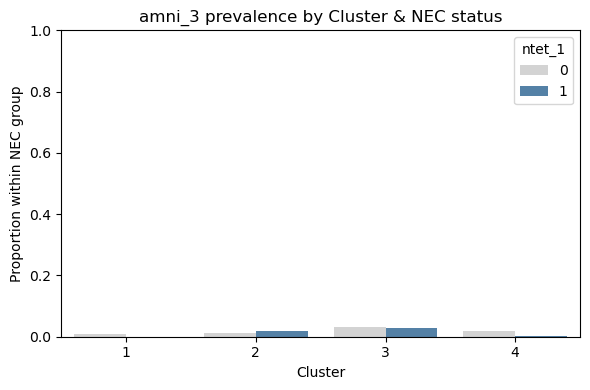

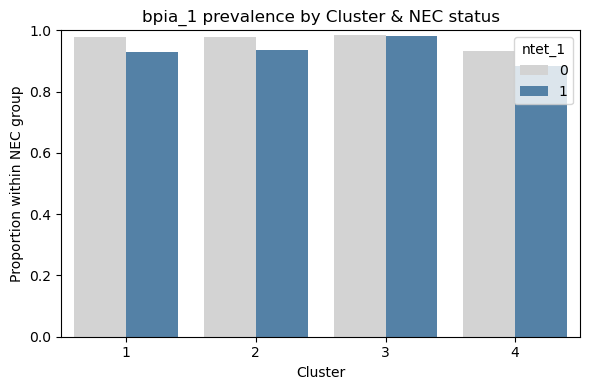

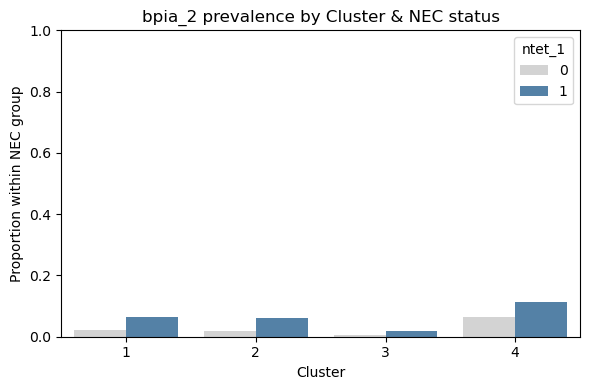

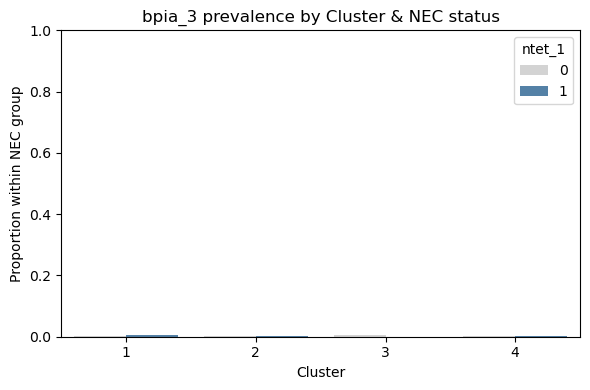

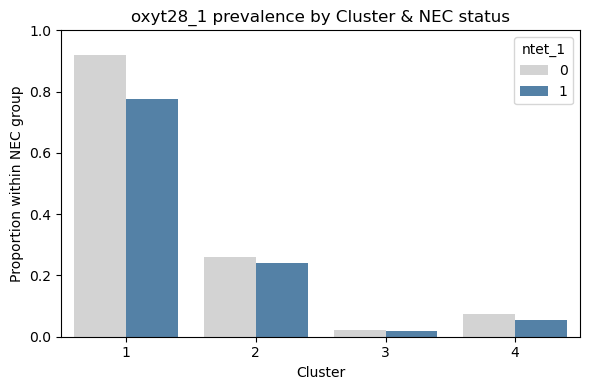

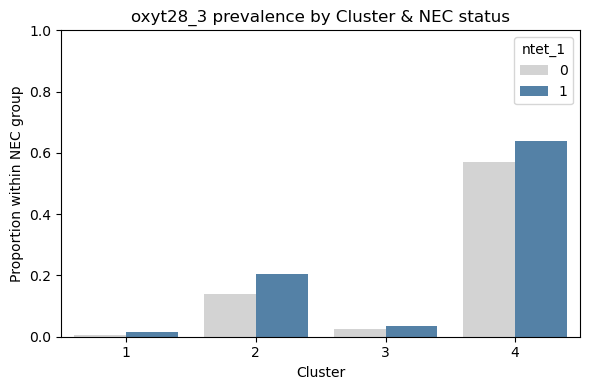

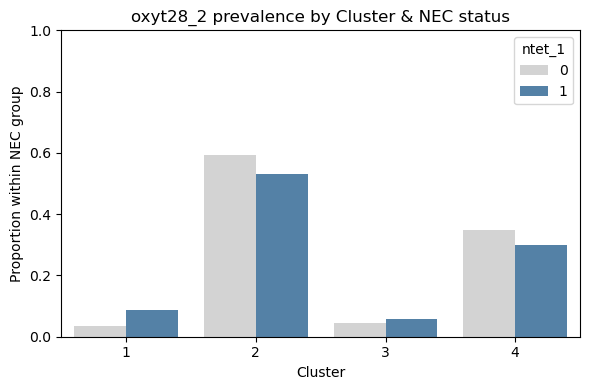

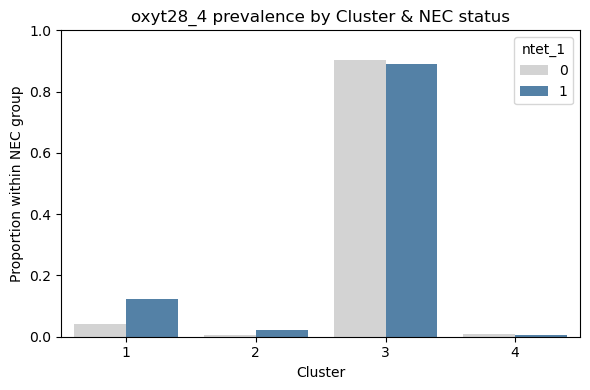

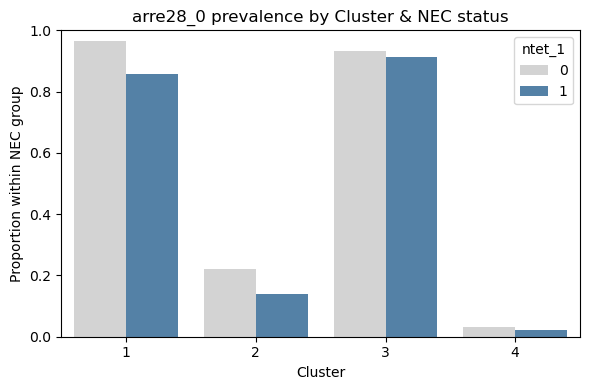

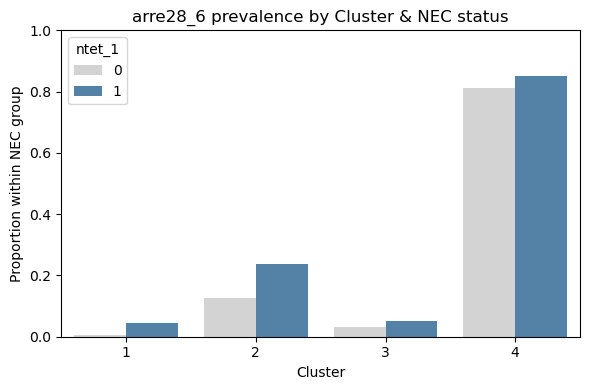

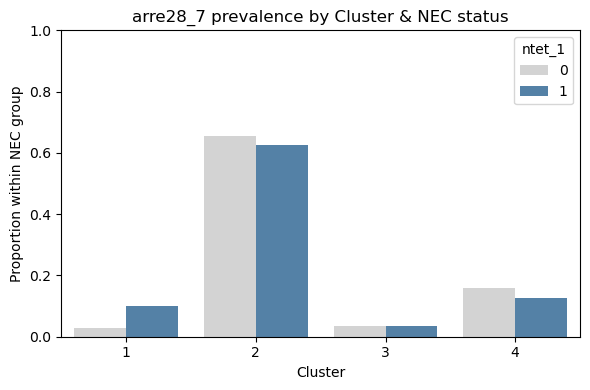

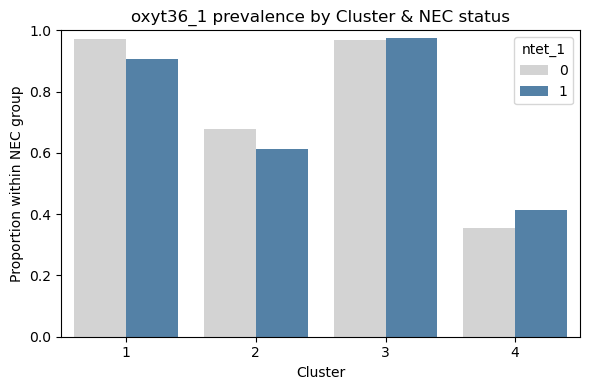

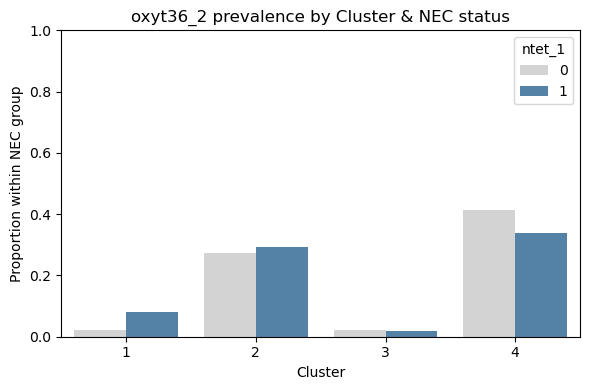

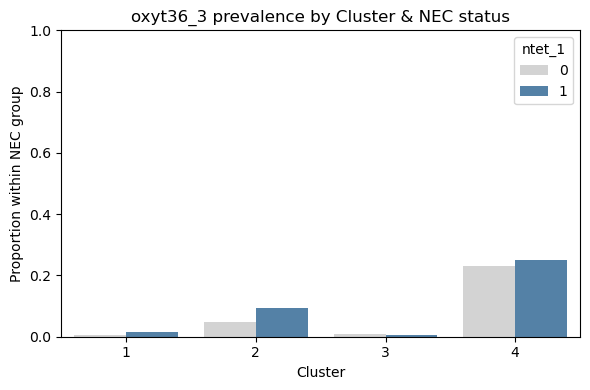

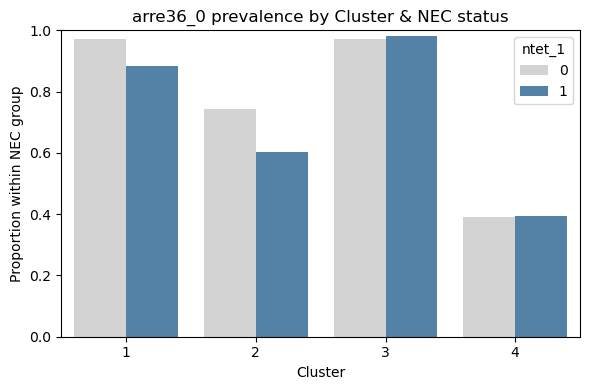

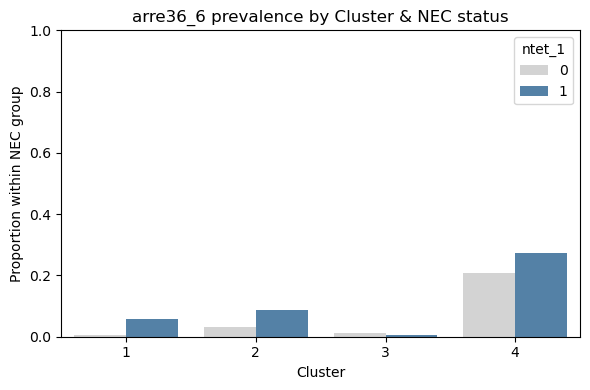

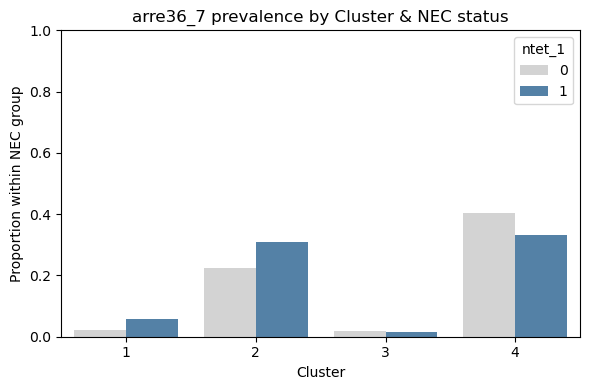

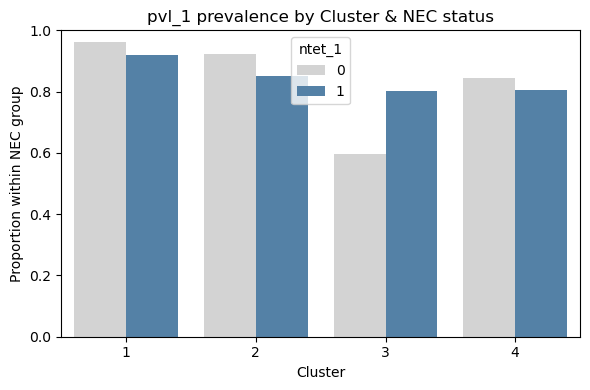

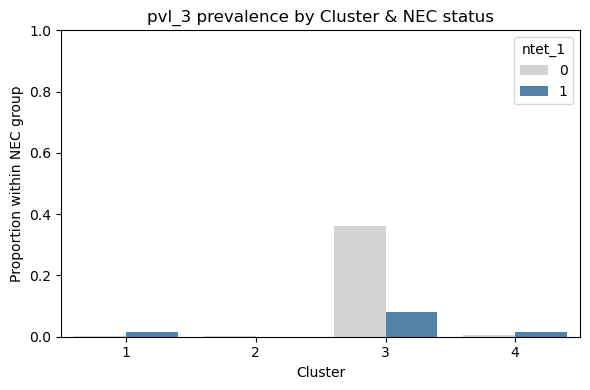

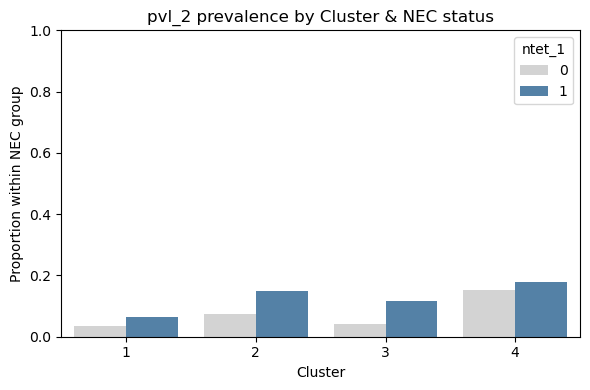

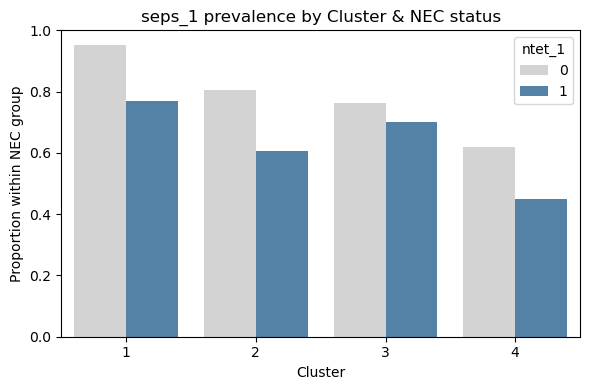

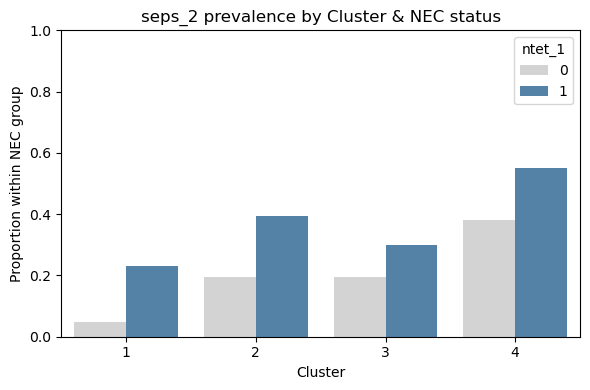

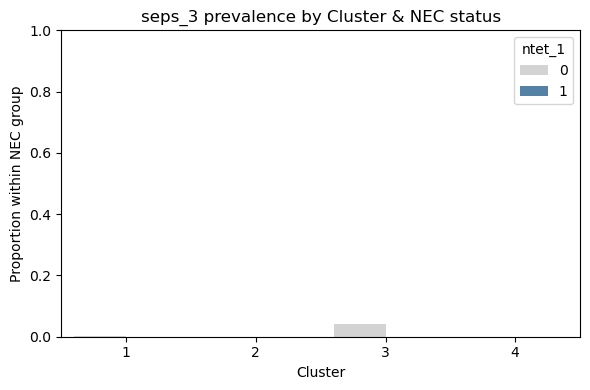

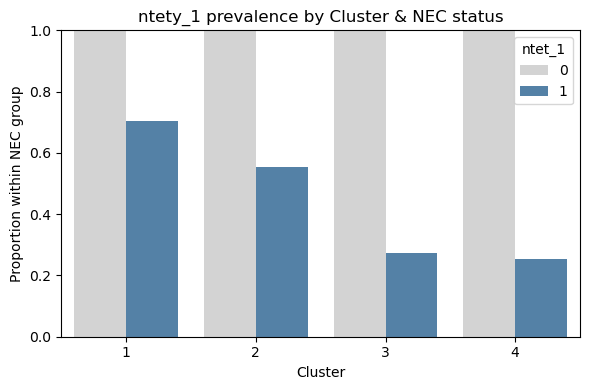

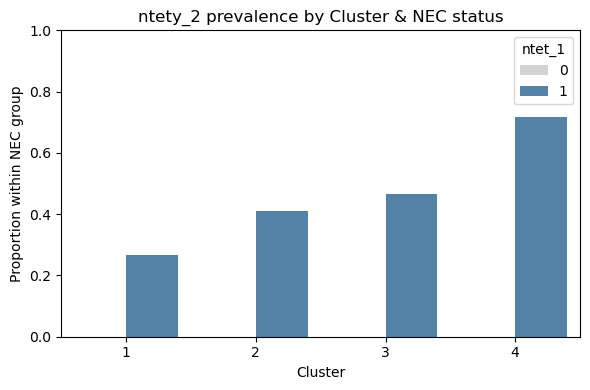

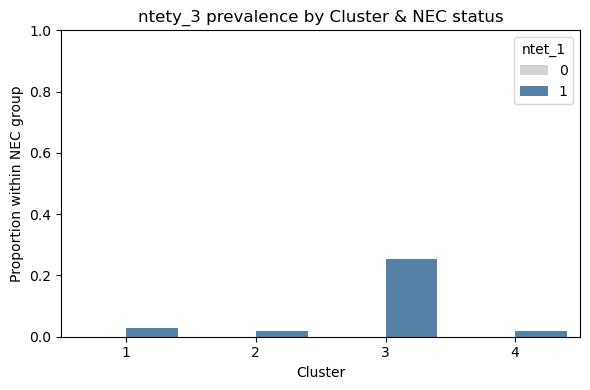

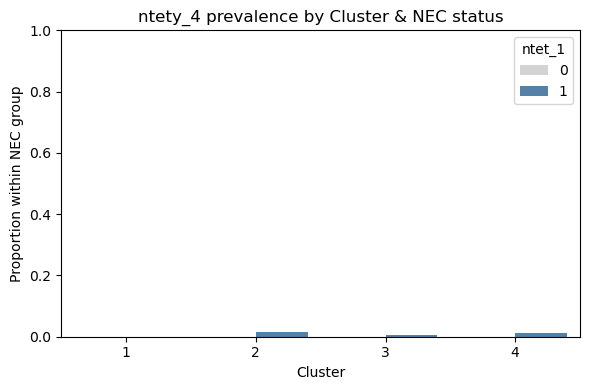

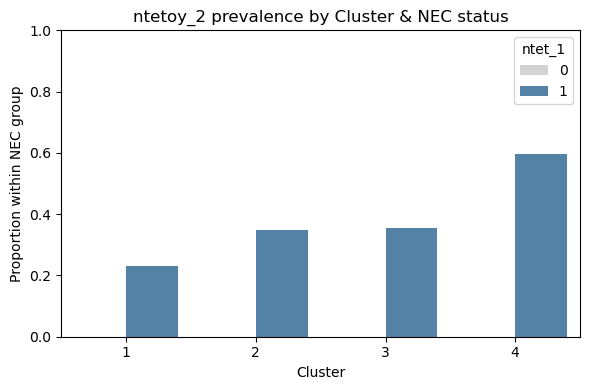

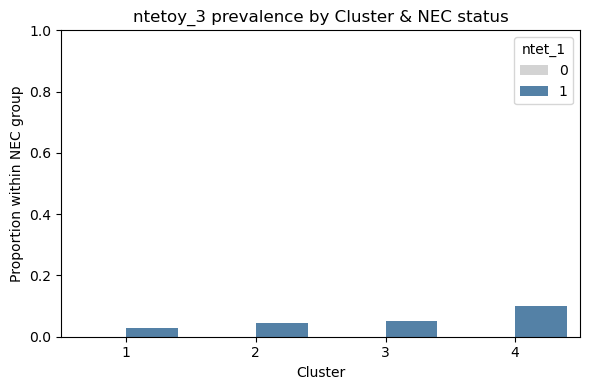

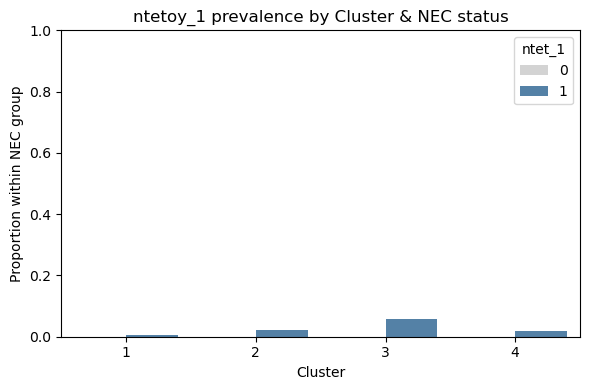

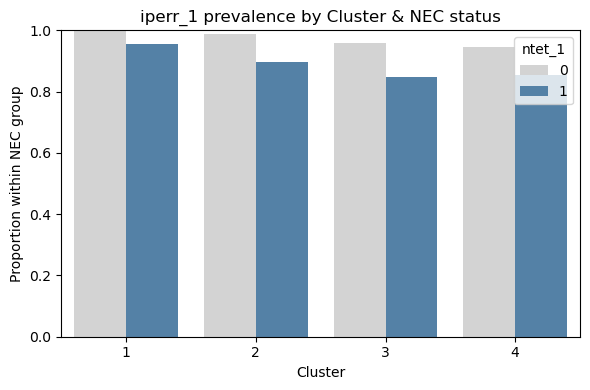

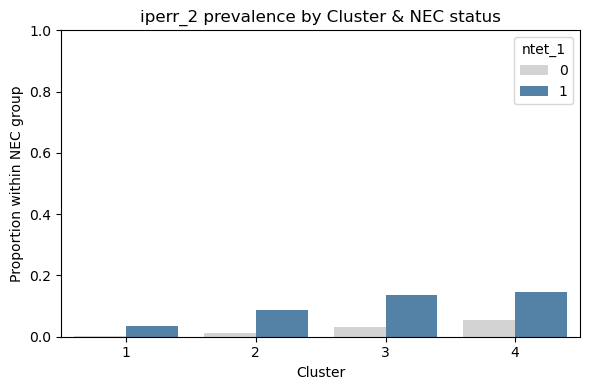

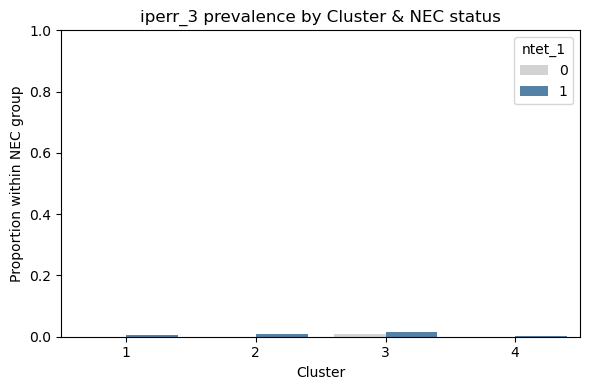

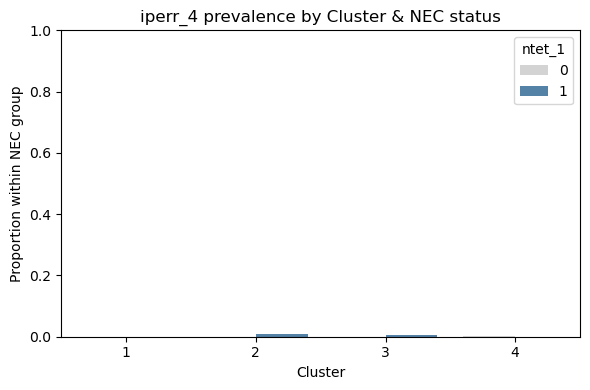

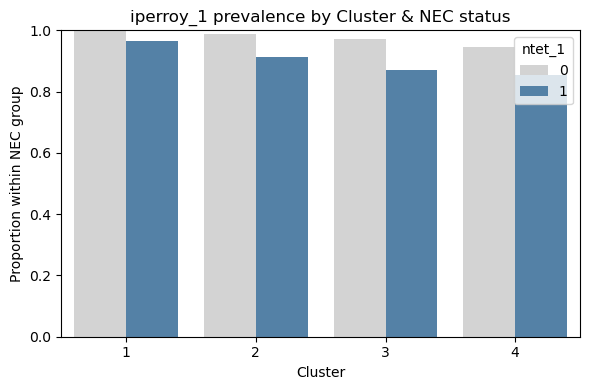

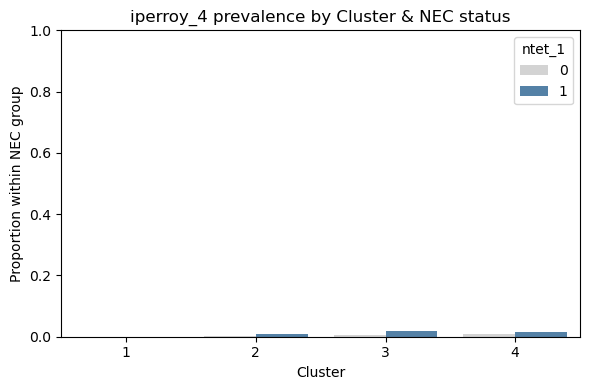

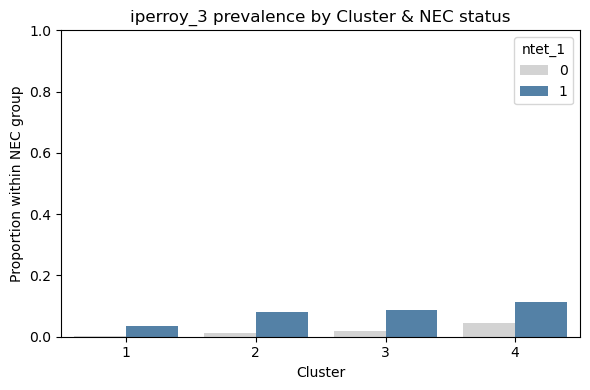

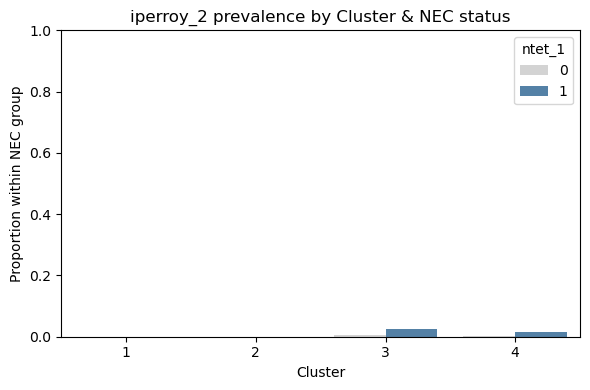

In [6]:
binary_cols = [
    col for col in df_scd.columns
    if col != 'ntet_1'
    and set(df_scd[col].dropna().unique()).issubset({0, 1})
]
continuous_cols = [c for c in df_scd.columns if c not in binary_cols]

# 3) 플롯용 DataFrame
df_plot = df_scd.copy()
df_plot['Cluster_Labels'] = cluster_labels

# 4) 연속형 변수: 한 피처당 클러스터·NEC(Boxplot)
for feat in continuous_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        x='Cluster_Labels',
        y=feat,
        hue='ntet_1',
        data=df_plot,
        palette={0: 'lightgrey', 1: 'salmon'}
    )
    plt.title(f'{feat} by Cluster & NEC status')
    plt.xlabel('Cluster')
    plt.ylabel(feat)
    plt.legend(title='ntet_1')
    plt.tight_layout()
    plt.show()

# 5) NEC 음성/양성 비율: 한 클러스터 전체 대비(합=1)
counts = df_plot.groupby(['Cluster_Labels','ntet_1']).size().unstack(fill_value=0)
props  = counts.div(counts.sum(axis=1), axis=0)
plot_df = props.reset_index().melt(
    id_vars='Cluster_Labels',
    var_name='ntet_1',
    value_name='proportion'
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Cluster_Labels',
    y='proportion',
    hue='ntet_1',
    data=plot_df,
    palette={0: 'lightgrey', 1: 'steelblue'}
)
plt.title('NEC status proportion by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion of cluster')
plt.ylim(0, 1)
plt.legend(title='ntet_1')
plt.tight_layout()
plt.show()

# 6) 이진형 변수(feature)별 NEC 그룹 내 발생 비율
prop_feat = (
    df_plot
    .groupby(['Cluster_Labels','ntet_1'], as_index=False)[binary_cols]
    .mean()
    .melt(
        id_vars=['Cluster_Labels','ntet_1'],
        var_name='feature',
        value_name='rate'
    )
)

for feat in binary_cols:
    df_prop = prop_feat[prop_feat['feature'] == feat]
    plt.figure(figsize=(6, 4))
    sns.barplot(
        x='Cluster_Labels',
        y='rate',
        hue='ntet_1',
        data=df_prop,
        palette={0: 'lightgrey', 1: 'steelblue'}
    )
    plt.title(f'{feat} prevalence by Cluster & NEC status')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion within NEC group')
    plt.ylim(0, 1)
    plt.legend(title='ntet_1')
    plt.tight_layout()
    plt.show()

In [9]:
df_plot = df_scd.copy()
df_plot['Cluster_Labels'] = cluster_labels

# 1) is_binary 함수 정의
def is_binary(series):
    vals = set(series.dropna().unique())
    return vals.issubset({0, 1})

# 2) binary_cols / continuous_cols 자동 분류
binary_cols = [c for c in df_plot.columns if c!='ntet_1' and is_binary(df_plot[c])]
continuous_cols = [c for c in df_plot.columns if c not in binary_cols + ['Cluster_Labels']]

clusters = sorted(df_plot['Cluster_Labels'].unique())

# 3) 결과 저장용 리스트
summary_records = []

# 4) PDF 하나에 모두 그리기 (원하면 개별 파일로도 분리 가능)
pdf_path = os.path.join(ipt_dir, "Binary_by_Cluster.pdf")
with PdfPages(pdf_path) as pdf:

    # (A) 클러스터별 NEC 상태 비율 (합 = 1)
    counts = df_plot.groupby(['Cluster_Labels','ntet_1']).size().unstack(fill_value=0)
    props  = counts.div(counts.sum(axis=1), axis=0)
    plot_df = props.reset_index().melt(
        id_vars='Cluster_Labels',
        var_name='ntet_1', value_name='proportion'
    )

    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Cluster_Labels', y='proportion',
        hue='ntet_1', data=plot_df,
        palette={0:'lightgrey',1:'steelblue'}
    )
    plt.title('NEC– Status Proportion by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion of cluster')
    plt.ylim(0,1)
    plt.legend(title='ntet_1')
    plt.tight_layout()
    pdf.savefig(); plt.close()

    # (B) 각 binary feature 별 “클러스터별 NEC 그룹 내 발생 비율”
    for feat in binary_cols:
        rows_plot = []
        for cl in clusters:
            df_cl = df_plot[df_plot['Cluster_Labels']==cl]
            # NEC−(0) 그룹, NEC+(1) 그룹 크기
            n_clust = len(df_cl)
            for status in [0,1]:
                sub = df_cl[df_cl['ntet_1']==status]
                count1 = sub[feat].sum()
                prop1  = count1 / n_clust if n_clust>0 else 0
                # summary 기록
                summary_records.append({
                    'Cluster': cl,
                    'Feature': feat,
                    'NEC_status': status,
                    'Cluster_Size': n_clust,
                    'Count_Pos': int(count1),
                    'Pct_Pos': prop1*100
                })
                rows_plot.append({
                    'Cluster': cl,
                    'NEC_status': status,
                    'Proportion_Pos': prop1
                })

        plot_feat = pd.DataFrame(rows_plot)
        plt.figure(figsize=(8,4))
        sns.barplot(
            x='Cluster', y='Proportion_Pos',
            hue='NEC_status', data=plot_feat,
            palette={0:'lightgrey',1:'salmon'}
        )
        plt.title(f'{feat} positive rate by Cluster & NEC status')
        plt.xlabel('Cluster')
        plt.ylabel('Proportion of cluster')
        plt.ylim(0,1)
        plt.legend(title='ntet_1')
        plt.tight_layout()
        pdf.savefig(); plt.close()

# 5) 요약 CSV로 저장
summary_df = pd.DataFrame(summary_records).sort_values(['Feature','Cluster','NEC_status'])
csv_path = os.path.join(ipt_dir, "Binary_summary_by_cluster.csv")
summary_df.to_csv(csv_path, index=False)

print("PDF saved to:", pdf_path)
print("Summary CSV saved to:", csv_path)

PDF saved to: C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/0531~/WholeExp/C4\Binary_by_Cluster.pdf
Summary CSV saved to: C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/0531~/WholeExp/C4\Binary_summary_by_cluster.csv


In [12]:
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])

# 2) 자동 분류: binary vs continuous
binary_cols = [
    c for c in df_scd.columns
    if c != 'ntet_1' and set(df_scd[c].dropna().unique()).issubset({0,1})
]
continuous_cols = [c for c in df_scd.columns if c not in binary_cols]

# 3) 플롯용 DataFrame
df_plot = df_scd.copy()
df_plot['Cluster_Labels'] = cluster_labels

clusters = sorted(df_plot['Cluster_Labels'].unique())
summary_records = []

# 4) PDF에 차트 모두 저장
pdf_path = os.path.join(ipt_dir, "Features_by_Cluster_and_NEC.pdf")
with PdfPages(pdf_path) as pdf:

    # A) 클러스터별 NEC 상태 비율 (합=1)
    counts = df_plot.groupby(['Cluster_Labels','ntet_1']).size().unstack(fill_value=0)
    props  = counts.div(counts.sum(axis=1), axis=0)
    plot_df = props.reset_index().melt(
        id_vars='Cluster_Labels', var_name='ntet_1', value_name='proportion'
    )

    plt.figure(figsize=(8,5))
    ax = sns.barplot(
        x='Cluster_Labels', y='proportion', hue='ntet_1',
        data=plot_df, palette={0:'lightgrey',1:'steelblue'}
    )
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)        # horizontal gridlines
    plt.title('NEC status proportion by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion of cluster')
    plt.ylim(0,1)
    # legend below plot
    plt.legend(title='ntet_1', loc='upper center',
               bbox_to_anchor=(0.5, -0.12), ncol=2)
    plt.tight_layout()
    pdf.savefig(); plt.close()

    # B) Binary features
    for feat in binary_cols:
        rows_plot = []
        for cl in clusters:
            df_cl = df_plot[df_plot['Cluster_Labels']==cl]
            n_clust = len(df_cl)
            for status in [0,1]:
                sub = df_cl[df_cl['ntet_1']==status]
                count1 = sub[feat].sum()
                prop1  = count1 / n_clust if n_clust>0 else 0
                summary_records.append({
                    'Feature': feat, 'Feature_Type': 'binary',
                    'Cluster': cl, 'NEC_status': status,
                    'Cluster_Size': n_clust, 'Count_Pos': int(count1),
                    'Pct_Pos': prop1 * 100
                })
                rows_plot.append({
                    'Cluster': cl, 'NEC_status': status,
                    'Proportion_Pos': prop1
                })

        plot_feat = pd.DataFrame(rows_plot)
        plt.figure(figsize=(8,4))
        ax = sns.barplot(
            x='Cluster', y='Proportion_Pos', hue='NEC_status',
            data=plot_feat, palette={0:'lightgrey',1:'salmon'}
        )
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        plt.title(f'{feat} positive rate by Cluster & NEC status')
        plt.xlabel('Cluster')
        plt.ylabel('Proportion of cluster')
        plt.ylim(0,1)

        # legend를 더 아래로
        plt.legend(
            title='ntet_1',
            loc='upper center',
            bbox_to_anchor=(0.5, -0.20),  # y 좌표를 더 낮춤
            ncol=2
        )
        # 아래쪽 마진 늘리기
        plt.subplots_adjust(bottom=0.25)

        plt.tight_layout()
        pdf.savefig(); plt.close()

    # C) Continuous features
    for feat in continuous_cols:
        # summary 기록
        for cl in clusters:
            df_cl = df_plot[df_plot['Cluster_Labels']==cl]
            for status in [0,1]:
                sub = df_cl[df_cl['ntet_1']==status][feat].dropna()
                summary_records.append({
                    'Feature': feat, 'Feature_Type': 'continuous',
                    'Cluster': cl, 'NEC_status': status,
                    'Group_Size': int((df_cl['ntet_1']==status).sum()),
                    'N_non_missing': int(sub.count()),
                    'Mean': sub.mean(), 'Std': sub.std(),
                    'Median': sub.median()
                })

        plt.figure(figsize=(8,5))
        ax = sns.boxplot(
            x='Cluster_Labels', y=feat, hue='ntet_1',
            data=df_plot, palette={0:'lightgrey',1:'salmon'}
        )
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        plt.title(f'{feat} distribution by Cluster & NEC status')
        plt.xlabel('Cluster')
        plt.ylabel(feat)
        plt.legend(title='ntet_1', loc='upper center',
                   bbox_to_anchor=(0.5, -0.12), ncol=2)
        plt.tight_layout()
        pdf.savefig(); plt.close()

# 5) summary CSV로 저장
summary_df = pd.DataFrame(summary_records)
csv_path = os.path.join(ipt_dir, "Feature_summary_by_cluster.csv")
summary_df.to_csv(csv_path, index=False)

print("PDF saved to:", pdf_path)
print("Summary CSV saved to:", csv_path)

PDF saved to: C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/0531~/WholeExp/C4\Features_by_Cluster_and_NEC.pdf
Summary CSV saved to: C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/0531~/WholeExp/C4\Feature_summary_by_cluster.csv
